<a href="https://www.kaggle.com/code/omborse771924/dubai-real-estate-sales-rentals-eda?scriptVersionId=323497099" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sergionefedov/dubai-real-estate-sales-and-rentals-20202026/rentals.csv
/kaggle/input/datasets/sergionefedov/dubai-real-estate-sales-and-rentals-20202026/off_plan.csv
/kaggle/input/datasets/sergionefedov/dubai-real-estate-sales-and-rentals-20202026/metro_stations.csv
/kaggle/input/datasets/sergionefedov/dubai-real-estate-sales-and-rentals-20202026/secondary_sales.csv
/kaggle/input/datasets/sergionefedov/dubai-real-estate-sales-and-rentals-20202026/area_prices_monthly.csv


## Loading Dataset

In [2]:
rentals = pd.read_csv("/kaggle/input/datasets/sergionefedov/dubai-real-estate-sales-and-rentals-20202026/rentals.csv")

off_plan = pd.read_csv("/kaggle/input/datasets/sergionefedov/dubai-real-estate-sales-and-rentals-20202026/off_plan.csv")

metro = pd.read_csv("/kaggle/input/datasets/sergionefedov/dubai-real-estate-sales-and-rentals-20202026/metro_stations.csv")

secondary = pd.read_csv("/kaggle/input/datasets/sergionefedov/dubai-real-estate-sales-and-rentals-20202026/secondary_sales.csv")

area_prices = pd.read_csv("/kaggle/input/datasets/sergionefedov/dubai-real-estate-sales-and-rentals-20202026/area_prices_monthly.csv")


## EDA



DATASET : Rentals

Shape: (25000, 24)

Columns:
['id', 'date_listed', 'community', 'zone', 'lat', 'lon', 'property_category', 'property_type', 'bedrooms', 'area_sqft', 'area_m2', 'view', 'furnishing', 'chiller_included', 'parking_spaces', 'metro_station', 'metro_line', 'metro_distance_min', 'to_burj_khalifa_km', 'contract_type', 'n_cheques', 'annual_rent_usd', 'rent_per_sqft_usd', 'rent_per_m2_usd']

Data Types:
id                     object
date_listed            object
community              object
zone                   object
lat                   float64
lon                   float64
property_category      object
property_type          object
bedrooms                int64
area_sqft               int64
area_m2               float64
view                   object
furnishing             object
chiller_included         bool
parking_spaces          int64
metro_station          object
metro_line             object
metro_distance_min      int64
to_burj_khalifa_km    float64
contract_type

,id,date_listed,community,zone,lat,lon,property_category,property_type,bedrooms,area_sqft,...,parking_spaces,metro_station,metro_line,metro_distance_min,to_burj_khalifa_km,contract_type,n_cheques,annual_rent_usd,rent_per_sqft_usd,rent_per_m2_usd
0,R000001,2024-12-20,Town Square,Nshama,25.02906,55.25610,apartment,1BR,1,748,...,1,Centrepoint,Red,373,18.79,yearly,6,13700,18,196
1,R000002,2021-07-06,Expo City,Dubai South,24.96152,55.15759,apartment,1BR,1,1011,...,2,Expo 2020,Red,7,28.73,yearly,6,12700,12,135
2,R000003,2023-05-10,Palm Jumeirah,Palm Jumeirah,25.10836,55.13304,apartment,1BR,1,825,...,2,Mashreq Bank,Red,44,17.32,yearly,1,59900,72,782
3,R000004,2021-12-30,Deira,Deira,25.28720,55.30205,apartment,1BR,1,755,...,1,Al Jafiliya,Red,62,10.39,yearly,1,9300,12,133
4,R000005,2023-12-08,The Views,The Greens,25.08438,55.18399,apartment,1BR,1,746,...,1,Dubai Internet City,Red,5,15.50,short_term,12,31300,41,451



MISSING VALUES
No Missing Values Found

Duplicate Rows: 0

Unique Values Per Column


,Column,Unique Values
0,id,25000
1,date_listed,1945
2,community,84
3,zone,52
4,lat,16339
5,lon,16190
6,property_category,2
7,property_type,9
8,bedrooms,7
9,area_sqft,6010



Statistical Summary


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,25000,25000,R000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_listed,25000,1945,2023-03-25,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
community,25000,84,Jumeirah Golf Estates,342,NaN,NaN,NaN,NaN,NaN,NaN,NaN
zone,25000,52,Jumeirah,2344,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lat,25000.0,NaN,NaN,NaN,25.109921,0.093214,24.88476,25.041645,25.0789,25.198213,25.31616
lon,25000.0,NaN,NaN,NaN,55.249857,0.077189,55.06531,55.184567,55.25514,55.295203,55.52984
property_category,25000,2,apartment,16294,NaN,NaN,NaN,NaN,NaN,NaN,NaN
property_type,25000,9,1BR,5159,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bedrooms,25000.0,NaN,NaN,NaN,2.52184,1.624078,0.0,1.0,3.0,4.0,6.0
area_sqft,25000.0,NaN,NaN,NaN,2212.72832,1792.284074,300.0,791.0,1481.0,3287.25,11118.0



Memory Usage: 17.46 MB

NUMERICAL FEATURE DISTRIBUTIONS


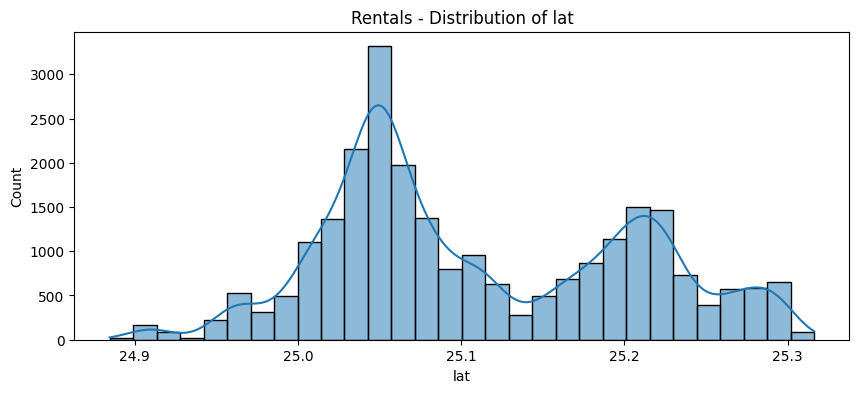

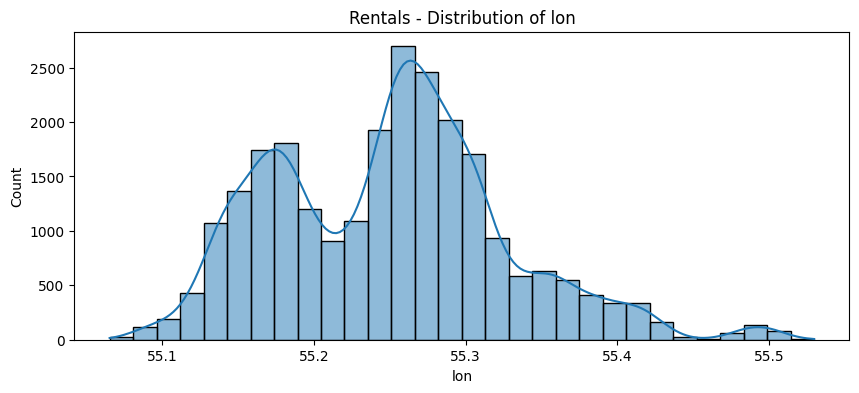

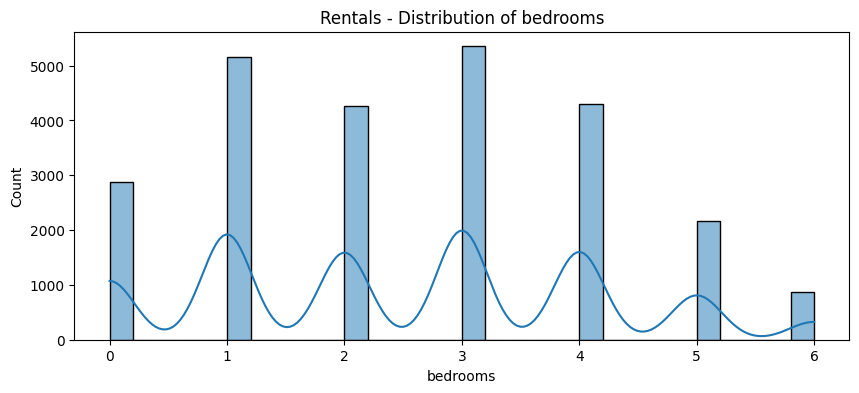

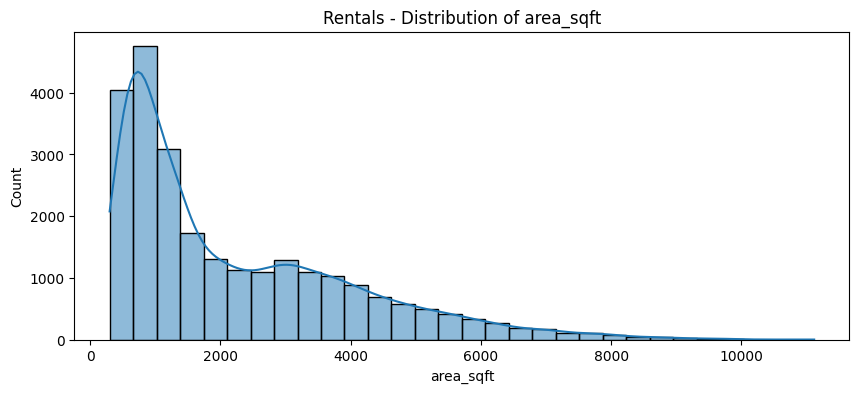

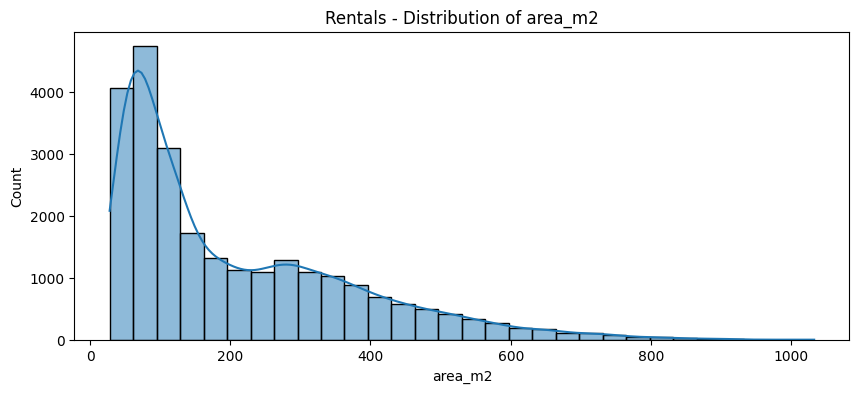

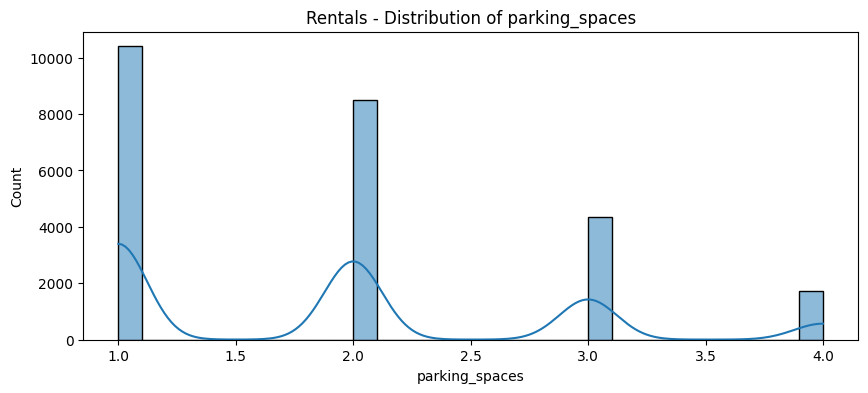

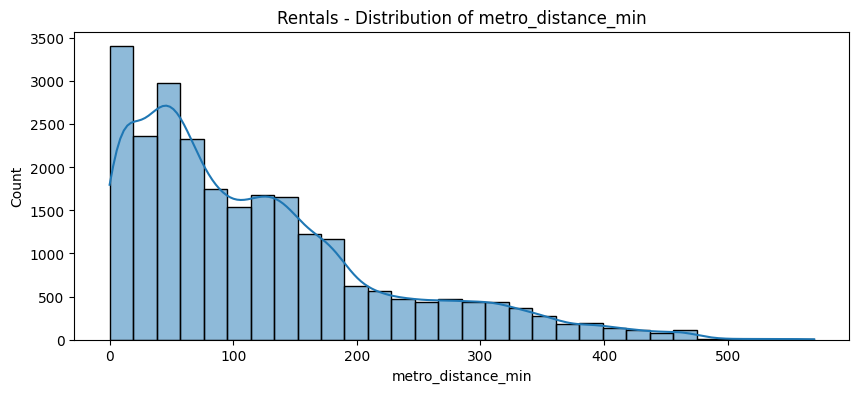

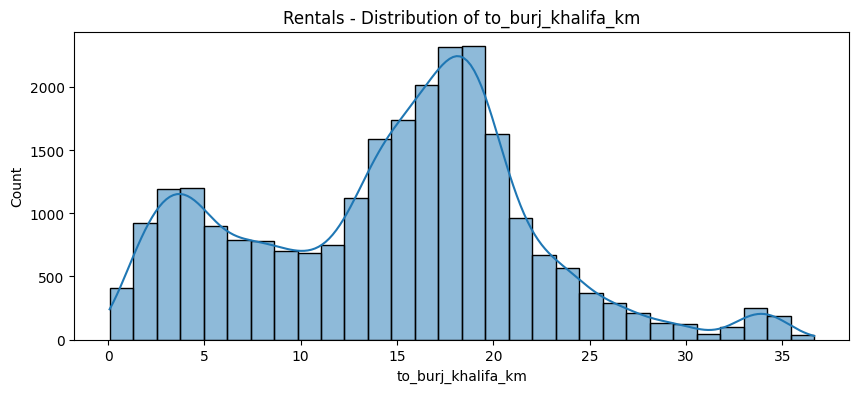

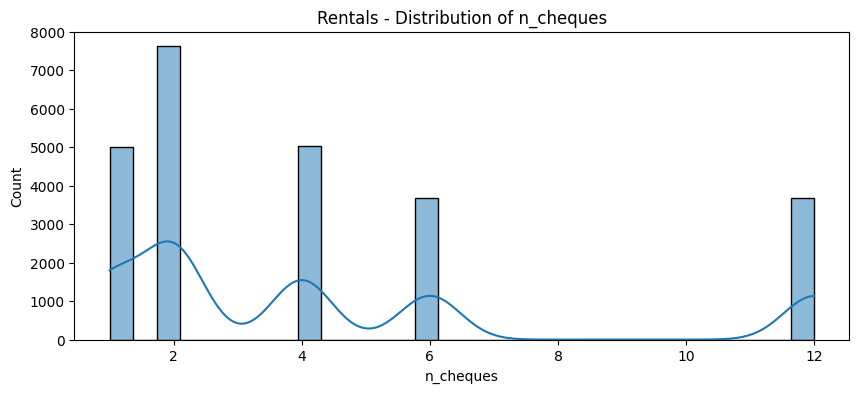

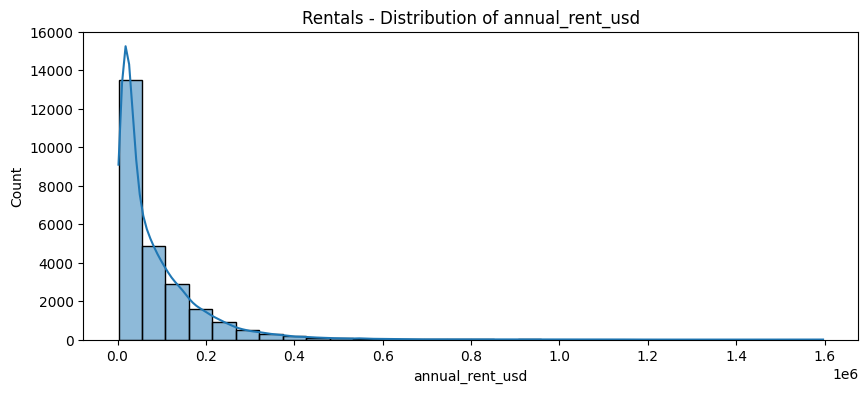

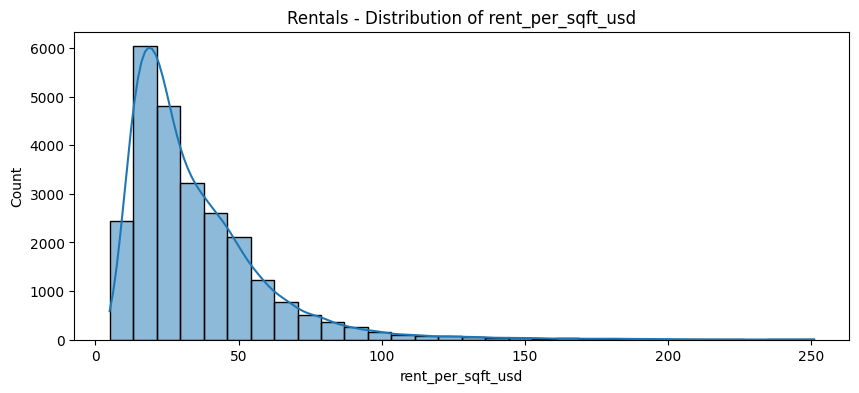

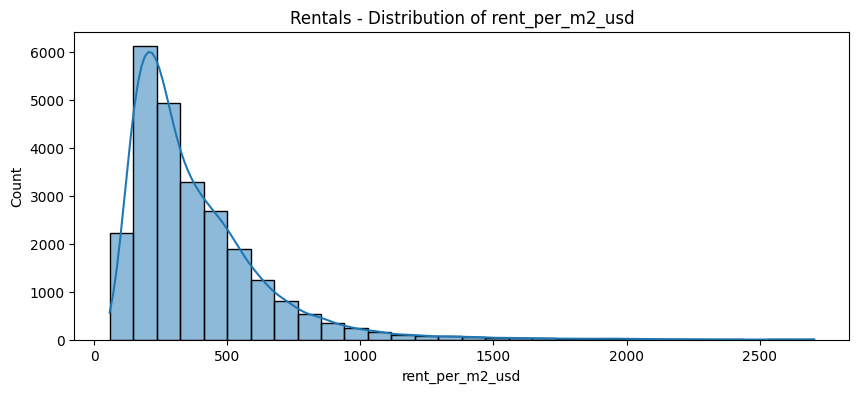


OUTLIER ANALYSIS


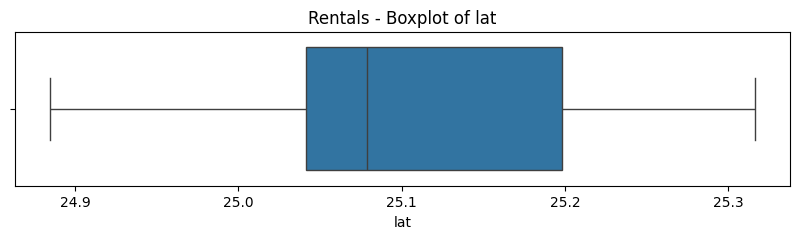

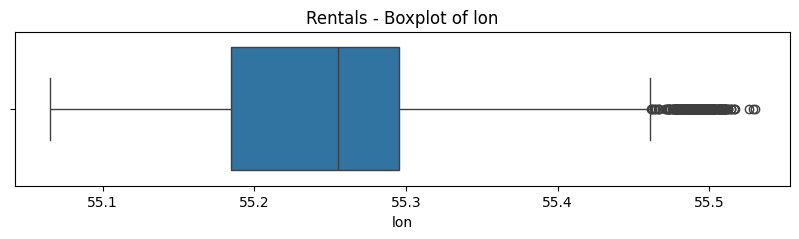

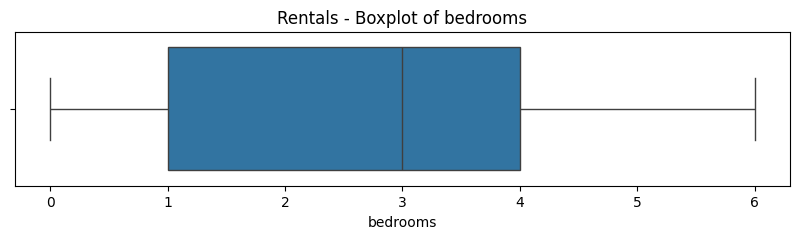

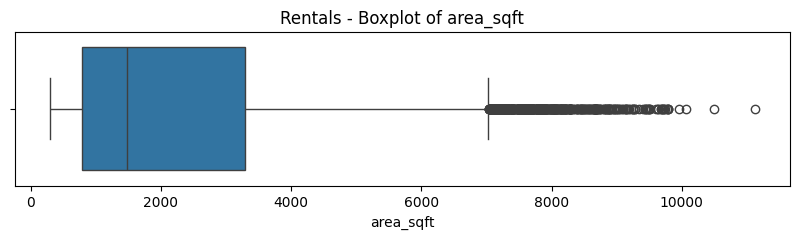

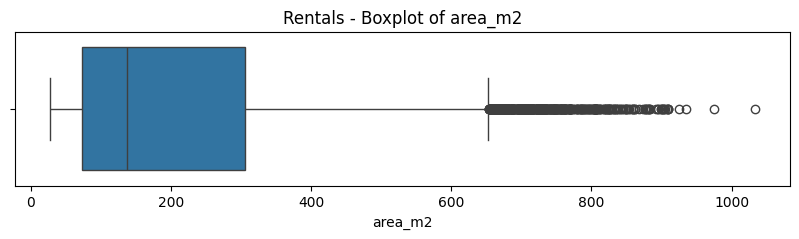

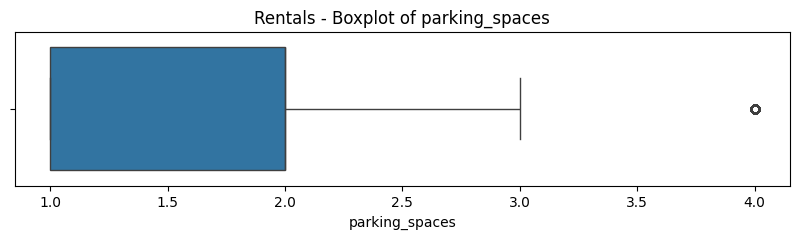

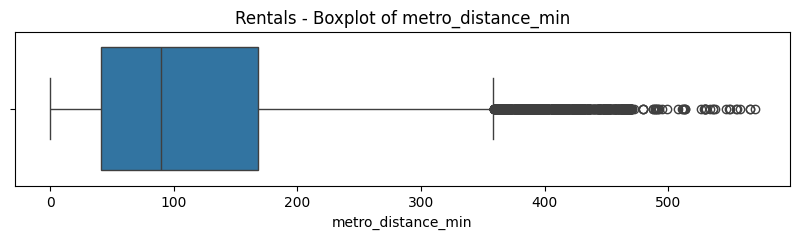

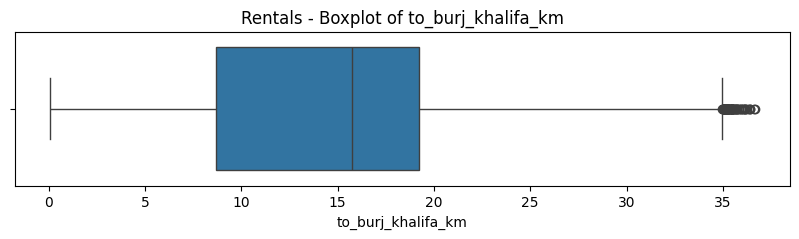

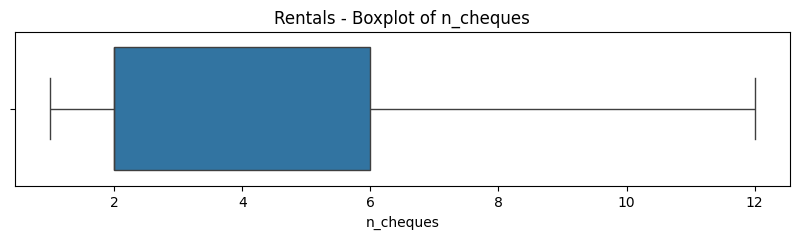

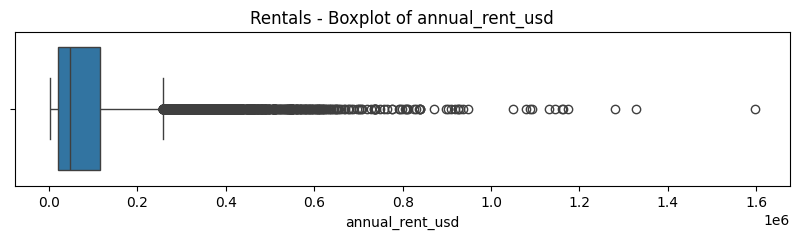

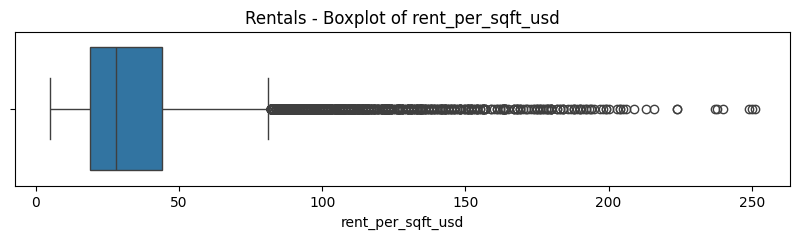

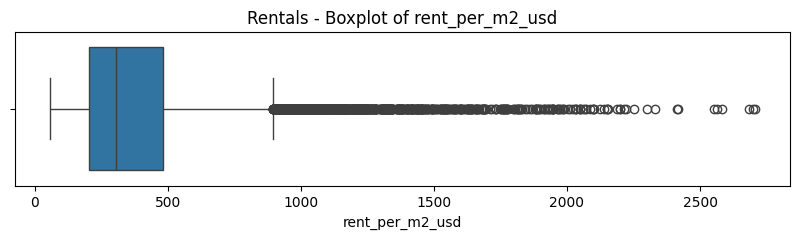


CORRELATION HEATMAP


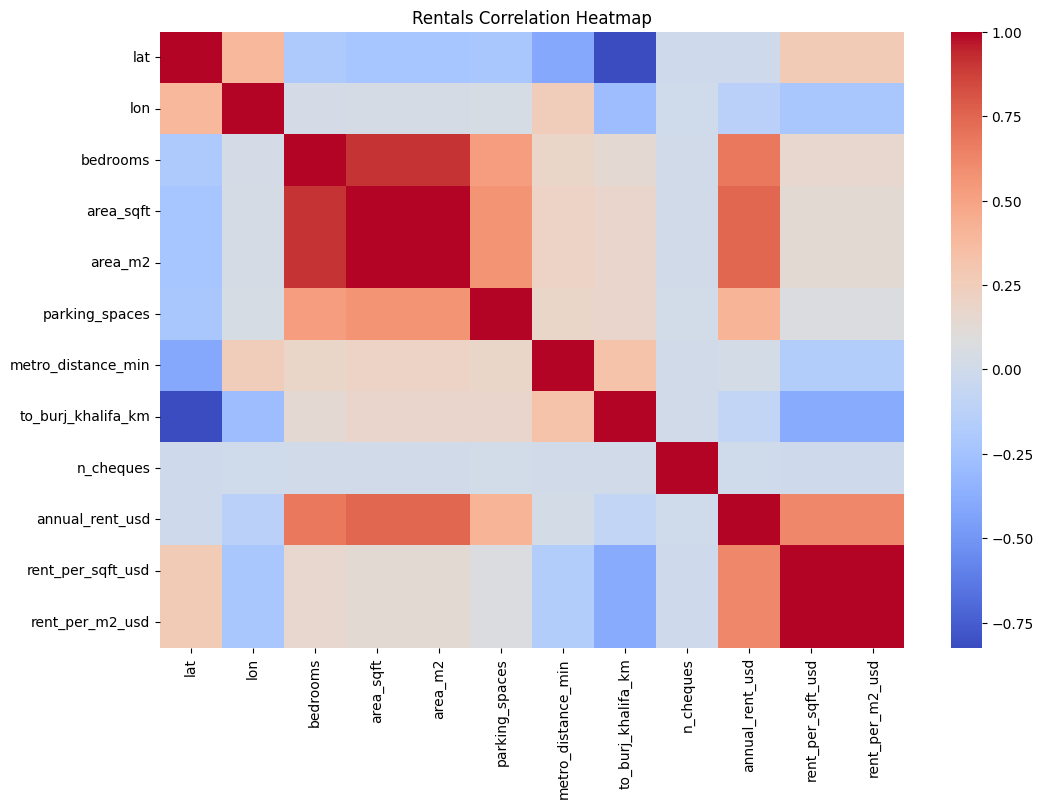


CATEGORICAL FEATURES

Top 10 Categories in id


id
R000001    1
R000002    1
R000003    1
R000004    1
R000005    1
R000006    1
R000007    1
R000008    1
R000009    1
R000010    1
Name: count, dtype: int64


Top 10 Categories in date_listed


date_listed
2023-03-25    25
2022-01-13    25
2025-12-09    25
2023-02-10    25
2023-11-26    24
2024-08-06    23
2023-10-02    23
2021-04-04    23
2021-06-13    23
2023-01-09    23
Name: count, dtype: int64


Top 10 Categories in community


...


MISSING VALUES
No Missing Values Found

Duplicate Rows: 0

Unique Values Per Column


,Column,Unique Values
0,id,12000
1,date_listed,1941
2,project_id,172
3,project_name,26
4,developer,16
5,developer_tier,2
6,community,71
7,zone,43
8,lat,168
9,lon,172



Statistical Summary


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,12000,12000,O000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_listed,12000,1941,2026-03-10,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
project_id,12000,172,OP0067,89,NaN,NaN,NaN,NaN,NaN,NaN,NaN
project_name,12000,26,Crest Grande,802,NaN,NaN,NaN,NaN,NaN,NaN,NaN
developer,12000,16,Binghatti,1130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
developer_tier,12000,2,tier2,6428,NaN,NaN,NaN,NaN,NaN,NaN,NaN
community,12000,71,Green Community,501,NaN,NaN,NaN,NaN,NaN,NaN,NaN
zone,12000,43,Jumeirah,1349,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lat,12000.0,NaN,NaN,NaN,25.091395,0.083011,24.9079,25.03393,25.0588,25.16539,25.28598
lon,12000.0,NaN,NaN,NaN,55.239187,0.071551,55.12049,55.17792,55.24223,55.28146,55.50704



Memory Usage: 10.46 MB

NUMERICAL FEATURE DISTRIBUTIONS


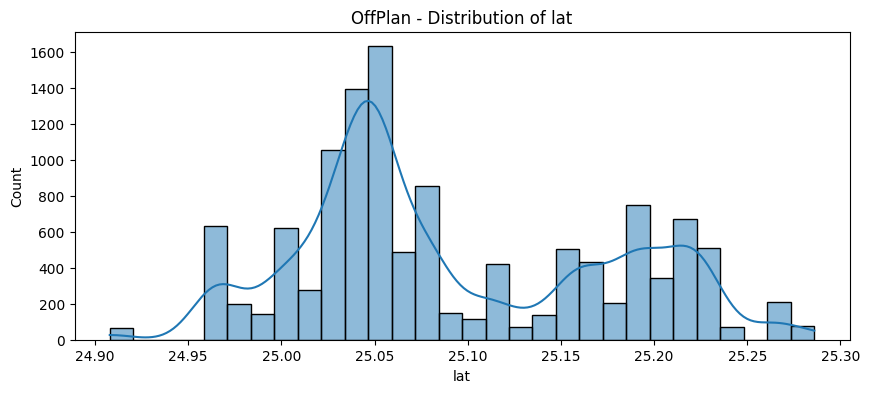

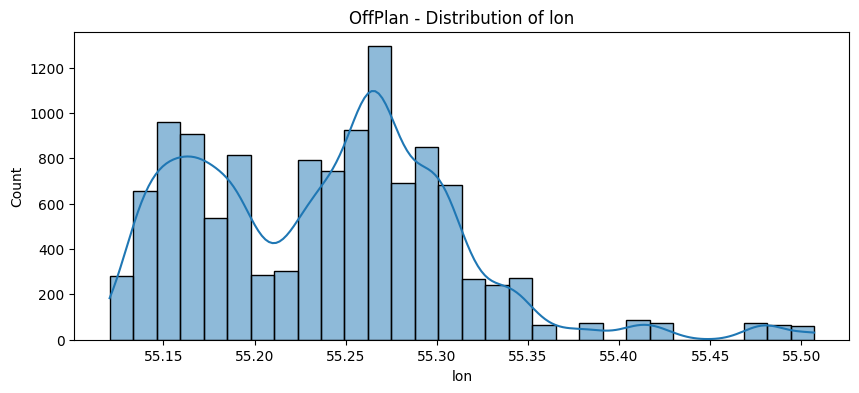

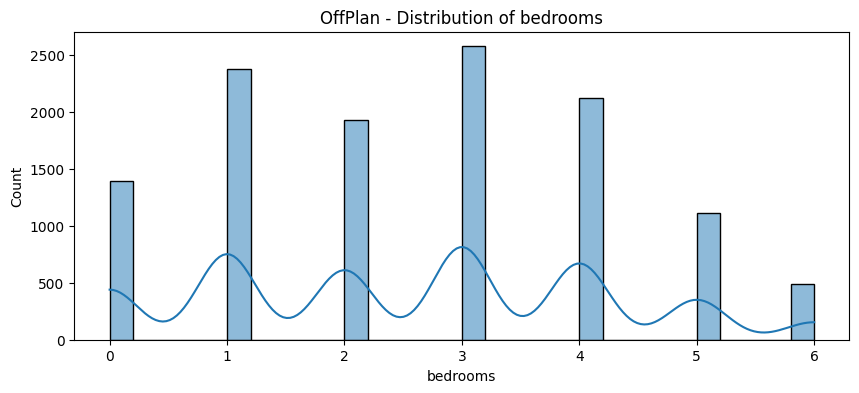

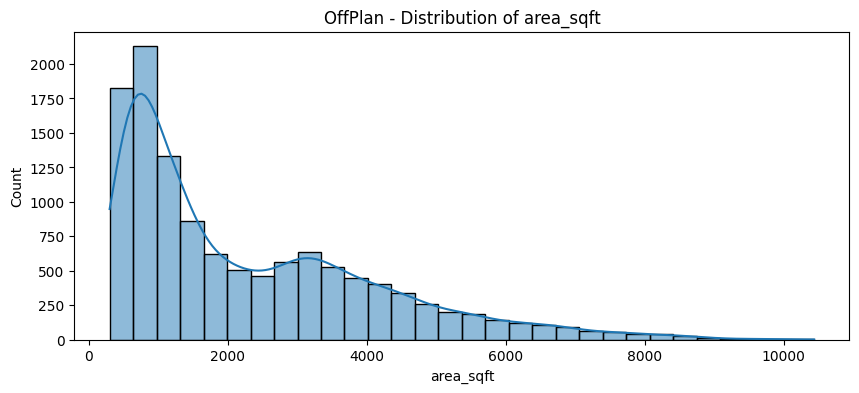

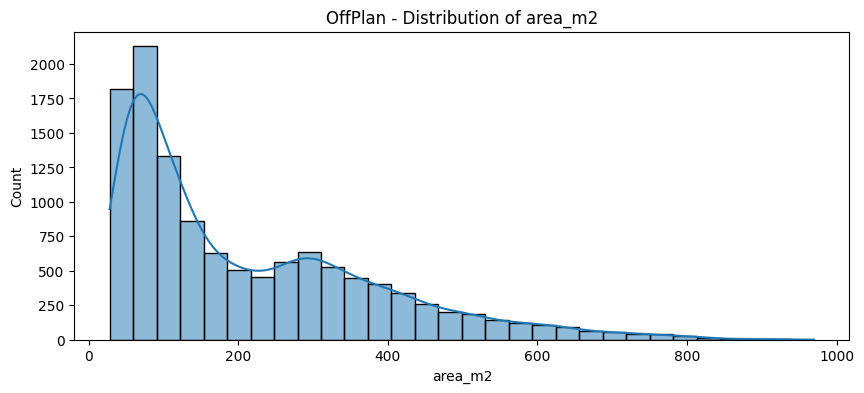

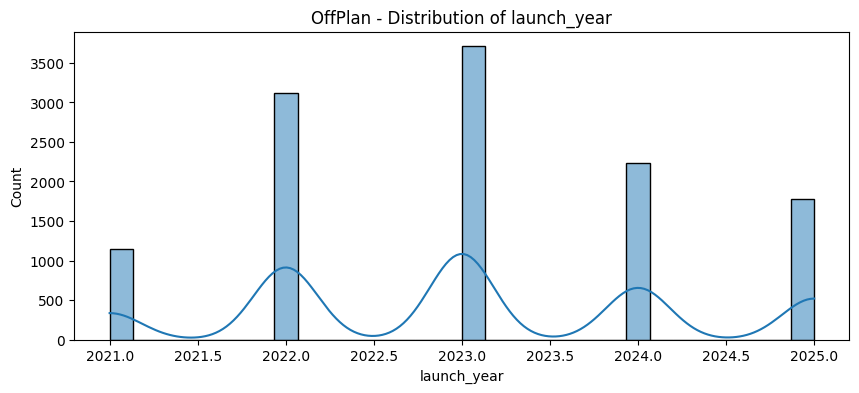

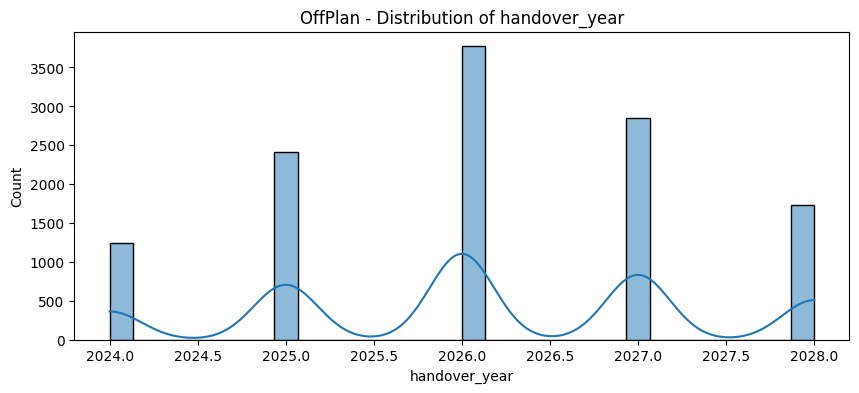

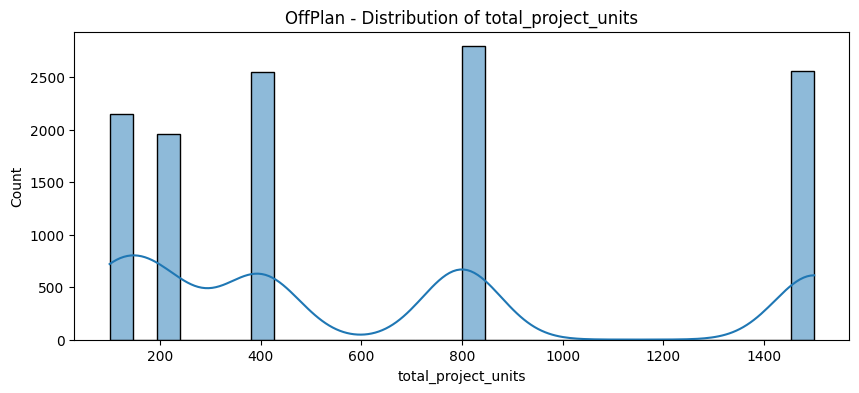

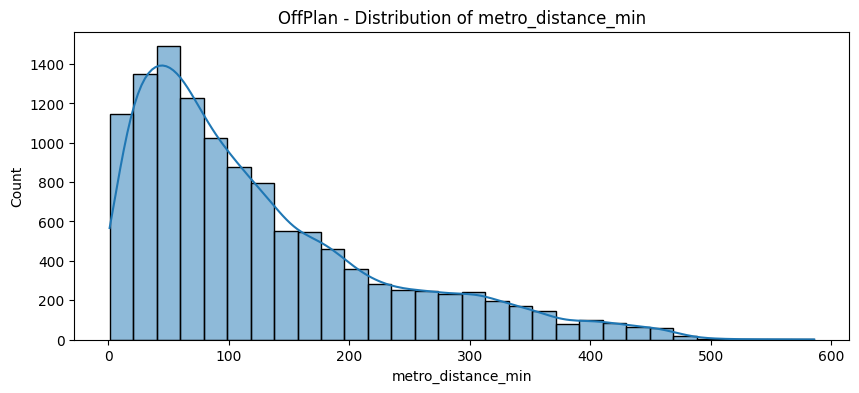

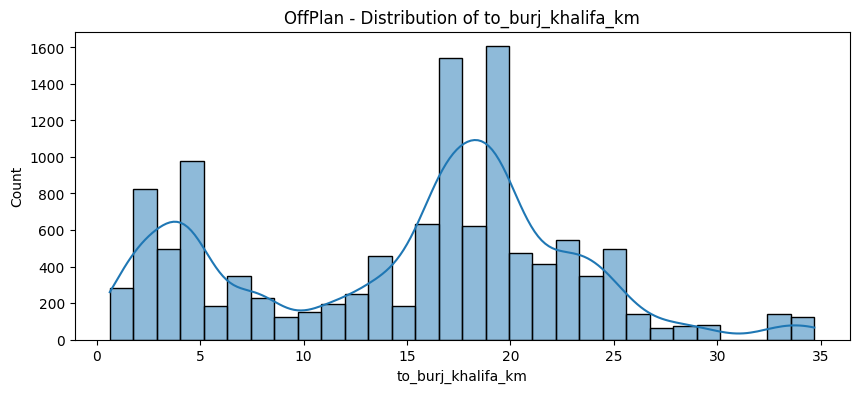

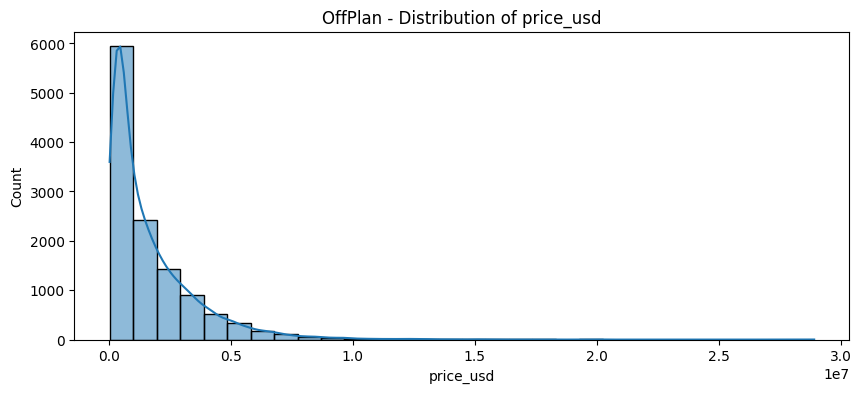

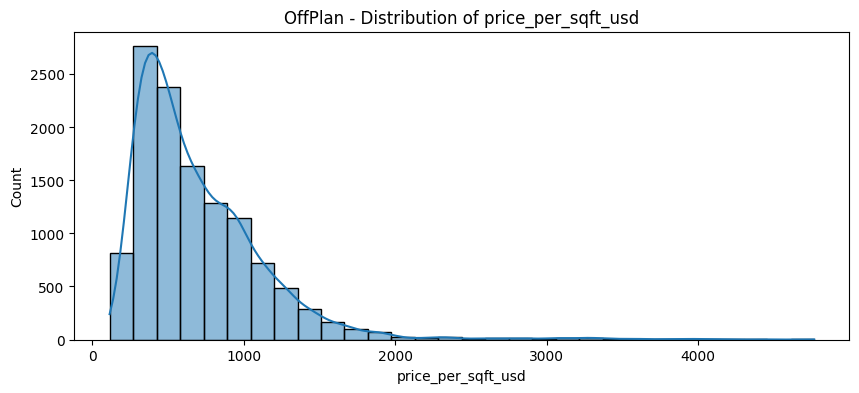

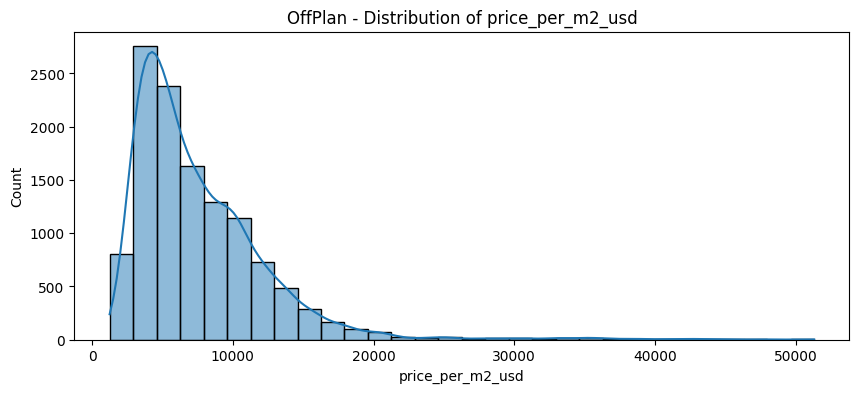

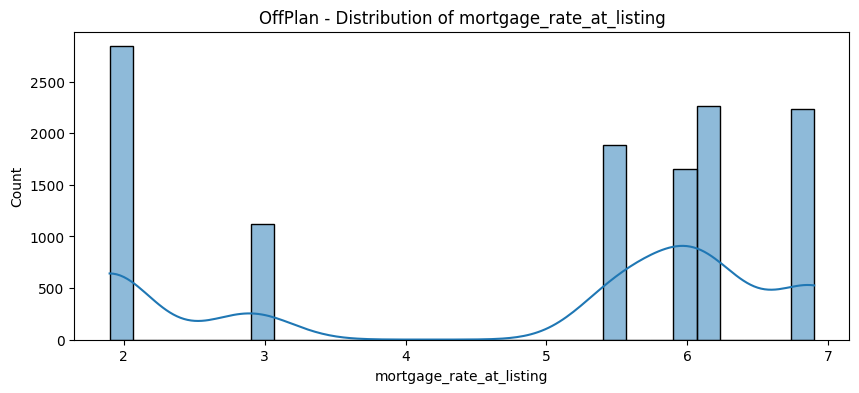


OUTLIER ANALYSIS


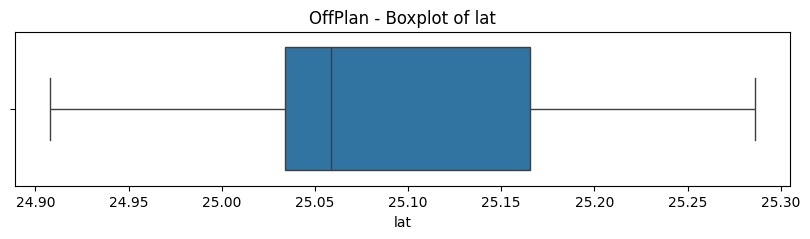

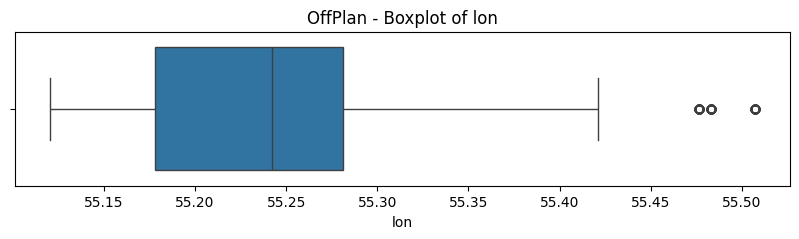

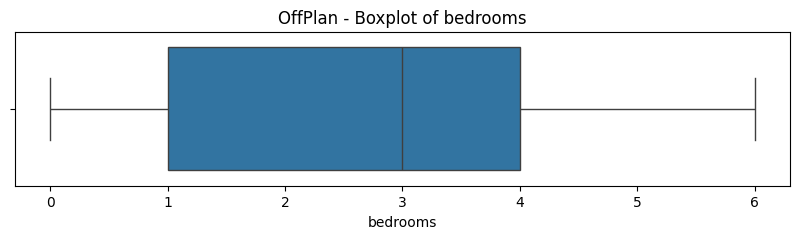

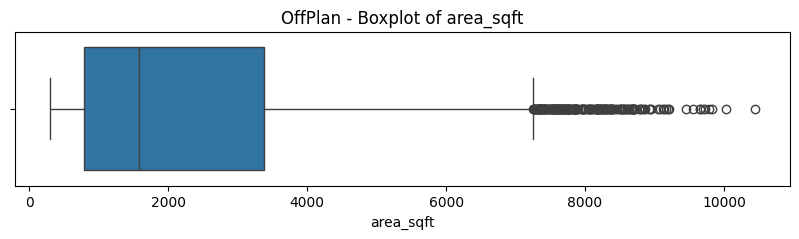

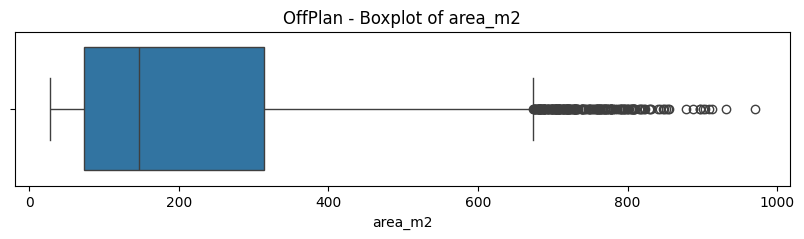

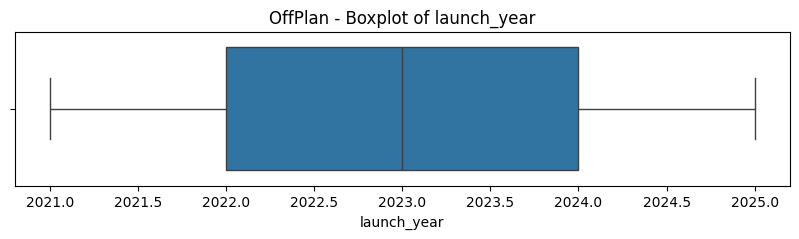

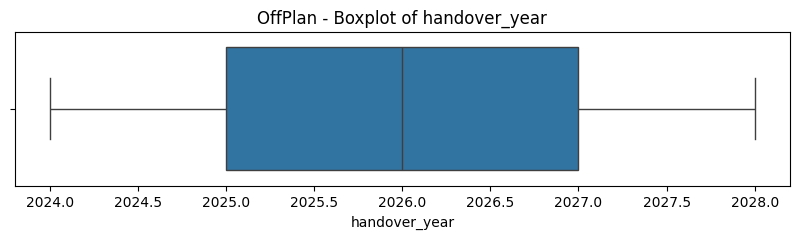

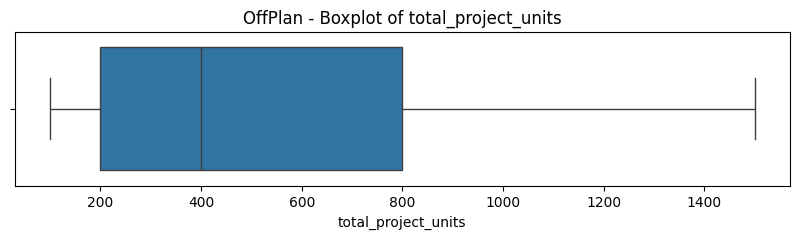

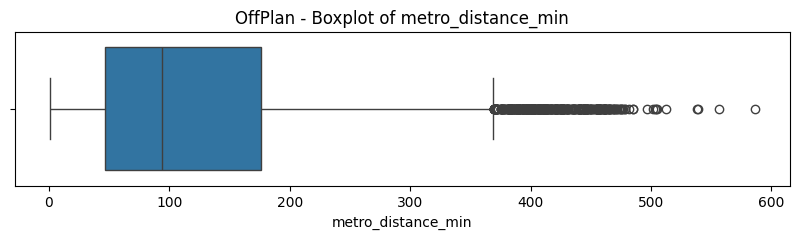

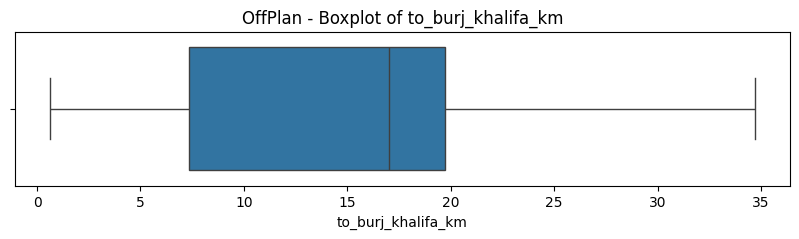

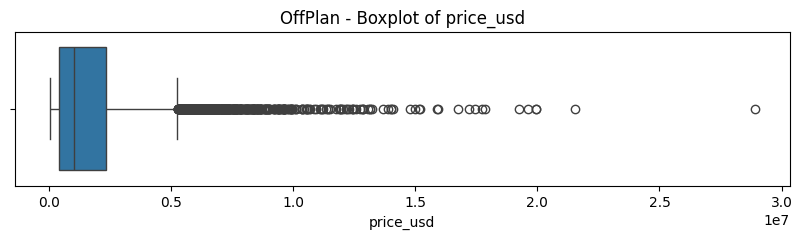

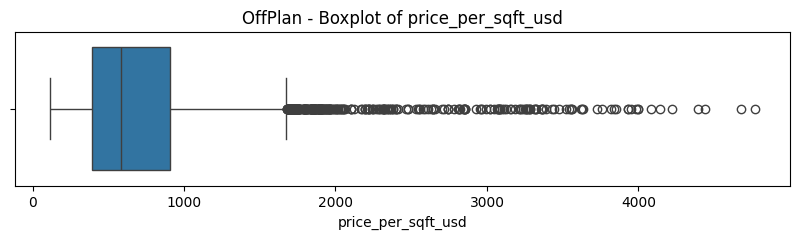

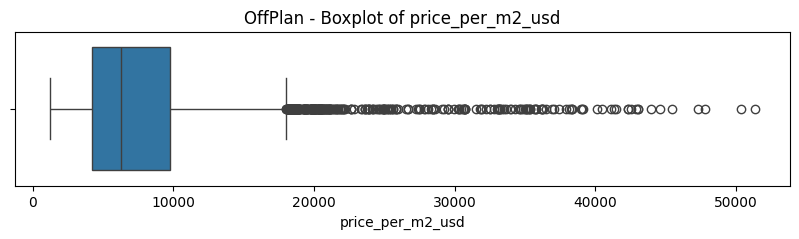

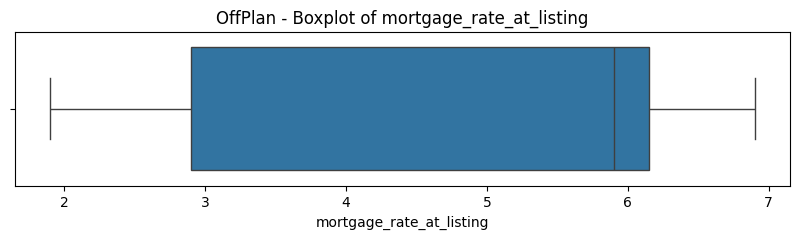


CORRELATION HEATMAP


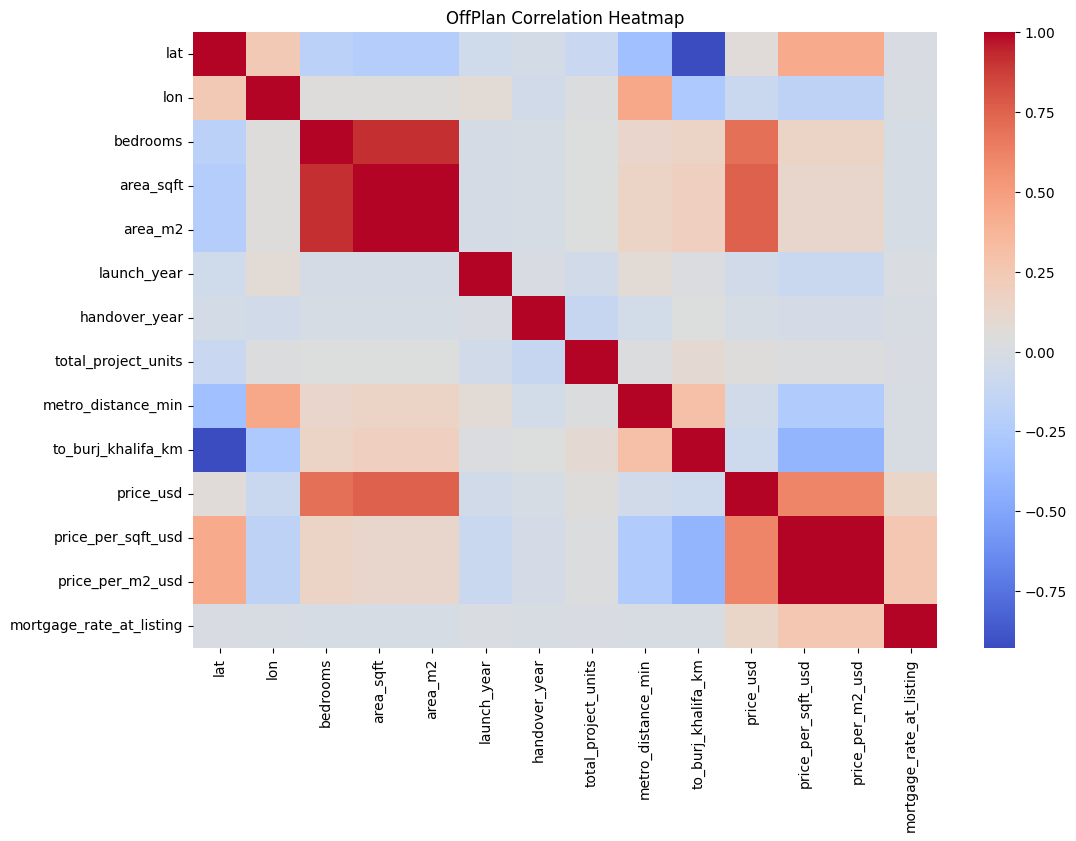


CATEGORICAL FEATURES

Top 10 Categories in id


id
O000001    1
O000002    1
O000003    1
O000004    1
O000005    1
O000006    1
O000007    1
O000008    1
O000009    1
O000010    1
Name: count, dtype: int64


Top 10 Categories in date_listed


date_listed
2026-03-10    17
2021-05-04    16
2022-08-27    14
2025-05-18    14
2024-11-07    14
2025-03-30    14
2025-12-03    14
2021-05-05    14
2022-07-30    13
2023-04-20    13
Name: count, dtype: int64


Top 10 Categories in project_id


...


MISSING VALUES
No Missing Values Found

Duplicate Rows: 0

Unique Values Per Column


,Column,Unique Values
0,station_name,55
1,line,2
2,lat,49
3,lon,43
4,year_opened,4
5,to_burj_khalifa_km,51



Statistical Summary


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
station_name,55,55,UAE Exchange,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
line,55,2,Red,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lat,55.0,NaN,NaN,NaN,25.188531,0.107871,24.956,25.1045,25.235,25.2685,25.295
lon,55.0,NaN,NaN,NaN,55.266753,0.087522,55.07,55.18125,55.298,55.329,55.392
year_opened,55.0,NaN,NaN,NaN,2011.563636,3.725605,2009.0,2009.5,2011.0,2011.0,2021.0
to_burj_khalifa_km,55.0,NaN,NaN,NaN,12.616,7.804503,0.32,7.26,10.82,14.6,32.11



Memory Usage: 0.01 MB

NUMERICAL FEATURE DISTRIBUTIONS


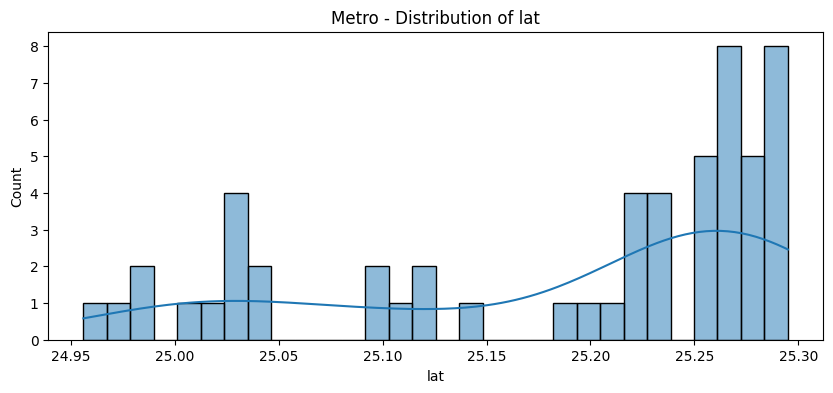

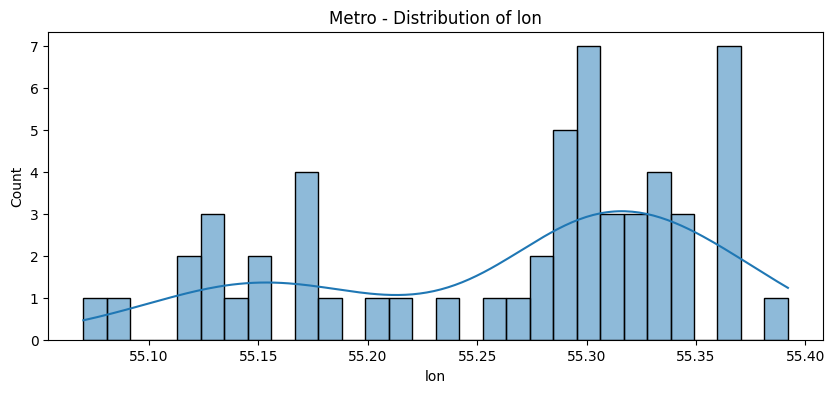

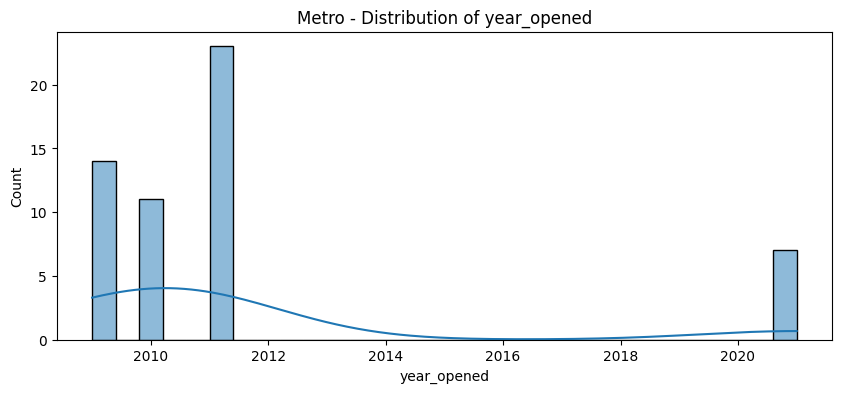

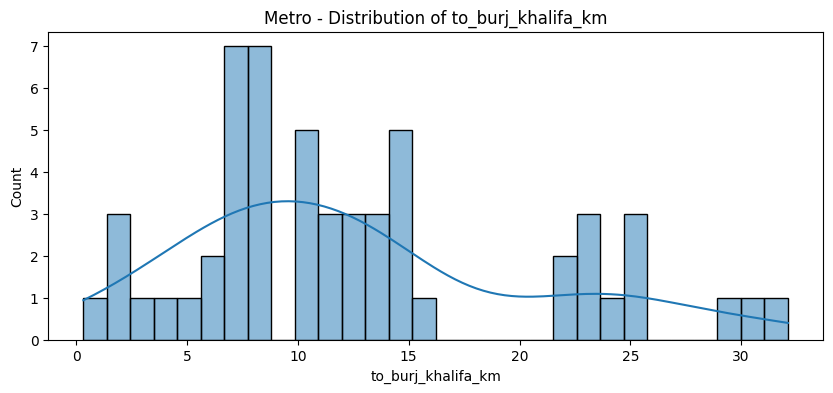


OUTLIER ANALYSIS


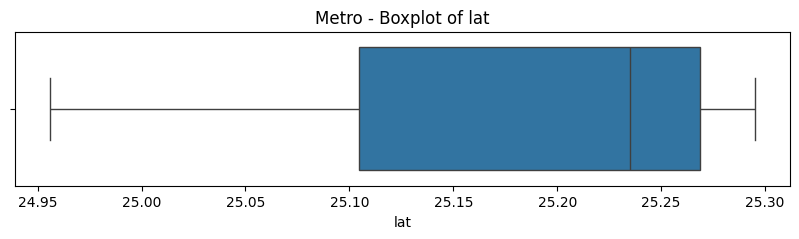

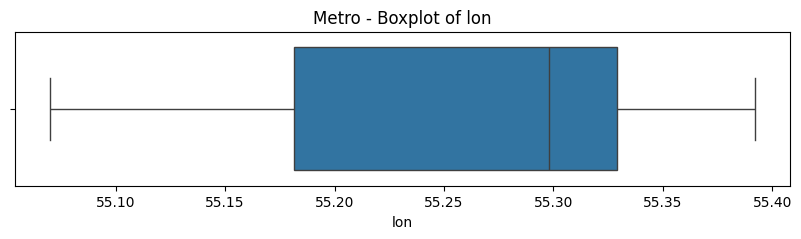

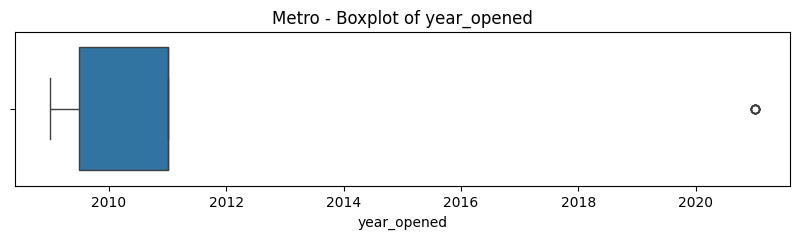

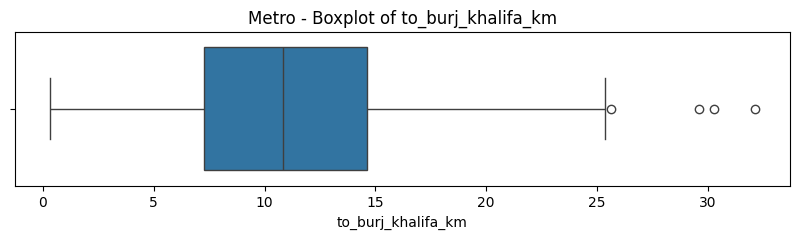


CORRELATION HEATMAP


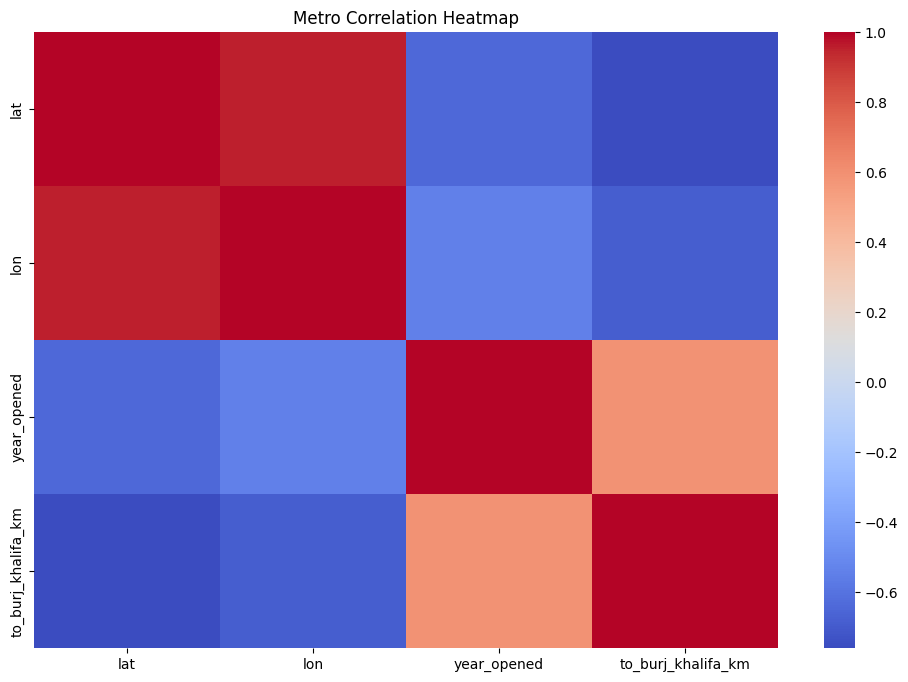


CATEGORICAL FEATURES

Top 10 Categories in station_name


station_name
UAE Exchange             1
Energy                   1
Ibn Battuta              1
Jebel Ali                1
Danube                   1
UAE Pavilion             1
MRT-1                    1
Discovery Gardens        1
Al Furjan                1
Jumeirah Golf Estates    1
Name: count, dtype: int64


Top 10 Categories in line


line
Red      37
Green    18
Name: count, dtype: int64


DATASET : SecondarySales

Shape: (50000, 29)

Columns:
['id', 'date_listed', 'community', 'zone', 'is_freehold', 'lat', 'lon', 'property_category', 'property_type', 'bedrooms', 'area_sqft', 'area_m2', 'floor', 'total_floors', 'year_built', 'view', 'furnishing', 'condition', 'parking_spaces', 'chiller_included', 'metro_station', 'metro_line', 'metro_distance_min', 'metro_distance_type', 'to_burj_khalifa_km', 'price_usd', 'price_per_sqft_usd', 'price_per_m2_usd', 'mortgage_rate_at_listing']

Data Types:
id                           object
date_listed                  object
community                    object
zone                         object
is_freehold                    bool
lat                         float64
lon                         float64
property_category            object
property_type                object
bedrooms                      int64
area_sqft                     int64
area_m2                     float64
floor                       float64
total_floors            

...


Duplicate Rows: 0

Unique Values Per Column


,Column,Unique Values
0,id,50000
1,date_listed,2311
2,community,84
3,zone,52
4,is_freehold,2
5,lat,24206
6,lon,23226
7,property_category,2
8,property_type,9
9,bedrooms,7



Statistical Summary


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,50000,50000,S000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_listed,50000,2311,2024-08-22,39,NaN,NaN,NaN,NaN,NaN,NaN,NaN
community,50000,84,DAMAC Lagoons,653,NaN,NaN,NaN,NaN,NaN,NaN,NaN
zone,50000,52,Jumeirah,4801,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_freehold,50000,2,True,44090,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lat,50000.0,NaN,NaN,NaN,25.109746,0.093276,24.88559,25.042047,25.07818,25.19833,25.31948
lon,50000.0,NaN,NaN,NaN,55.25015,0.077088,55.06197,55.18458,55.25522,55.294905,55.52416
property_category,50000,2,apartment,32180,NaN,NaN,NaN,NaN,NaN,NaN,NaN
property_type,50000,9,1BR,10190,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bedrooms,50000.0,NaN,NaN,NaN,2.54916,1.636544,0.0,1.0,3.0,4.0,6.0



Memory Usage: 39.02 MB

NUMERICAL FEATURE DISTRIBUTIONS


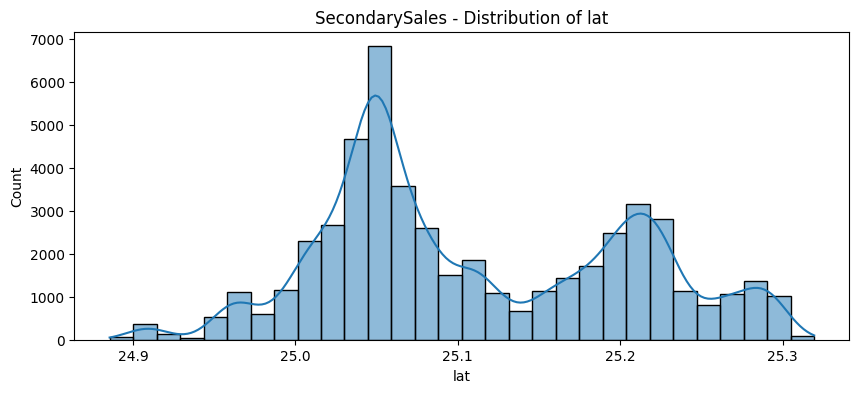

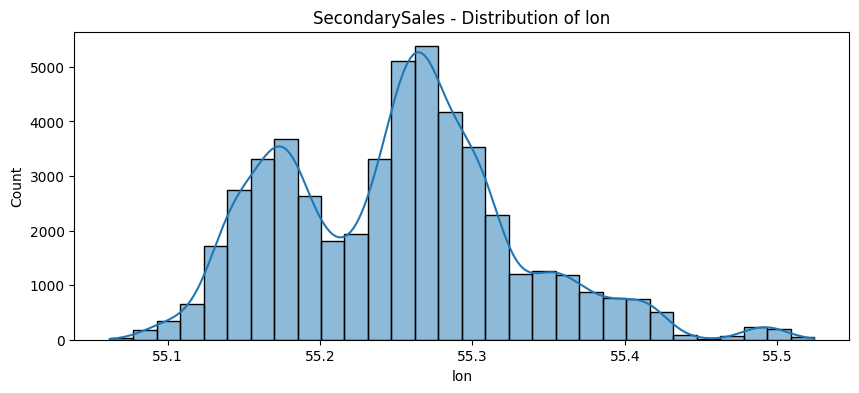

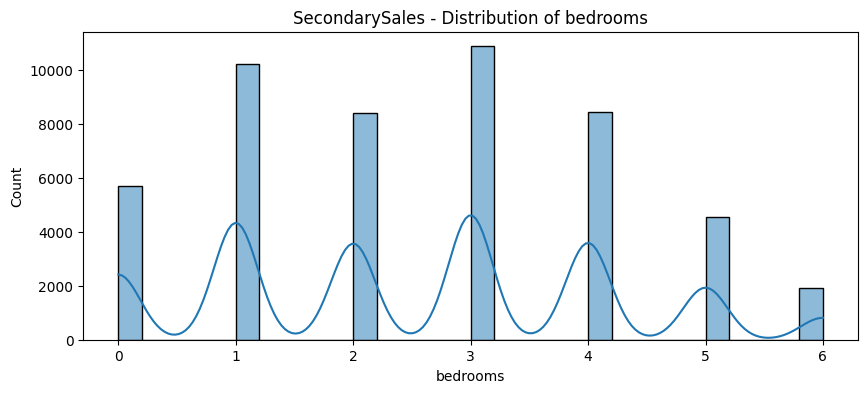

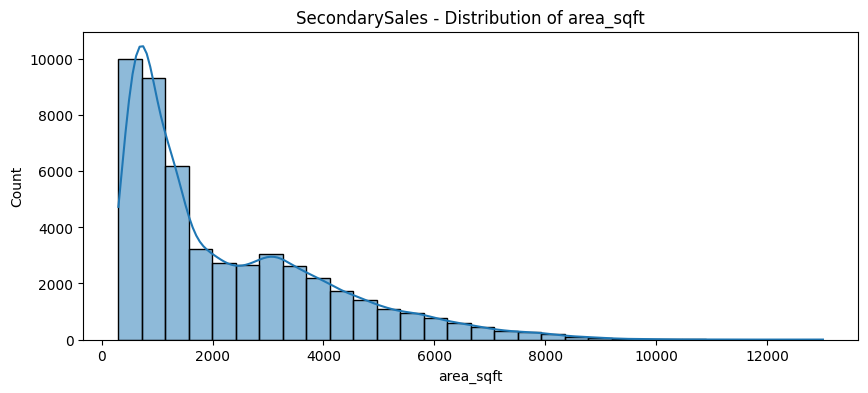

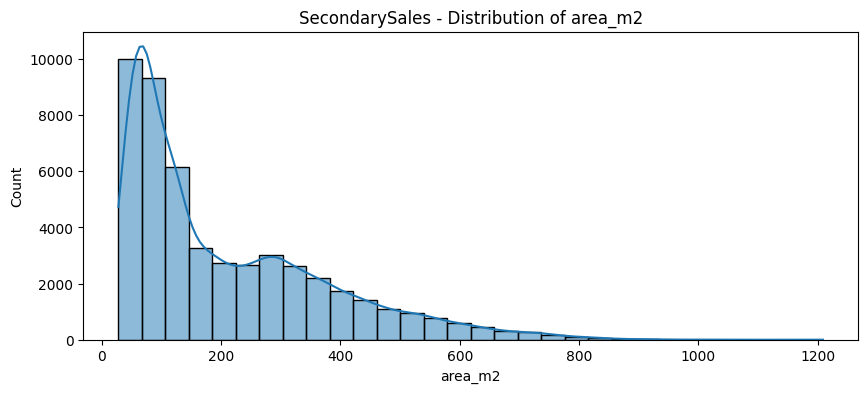

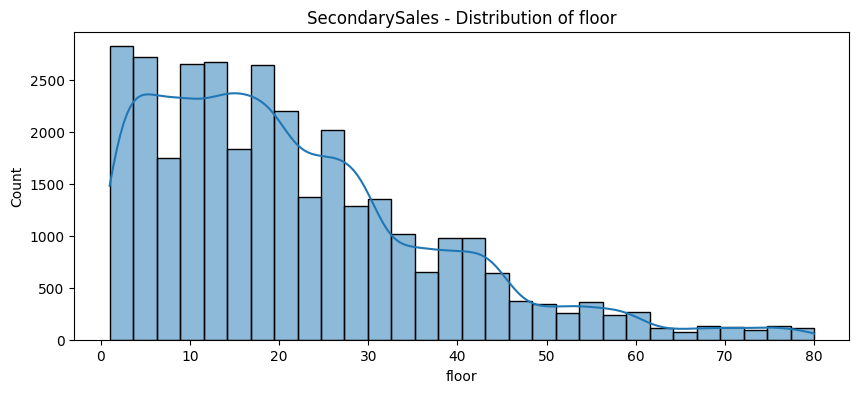

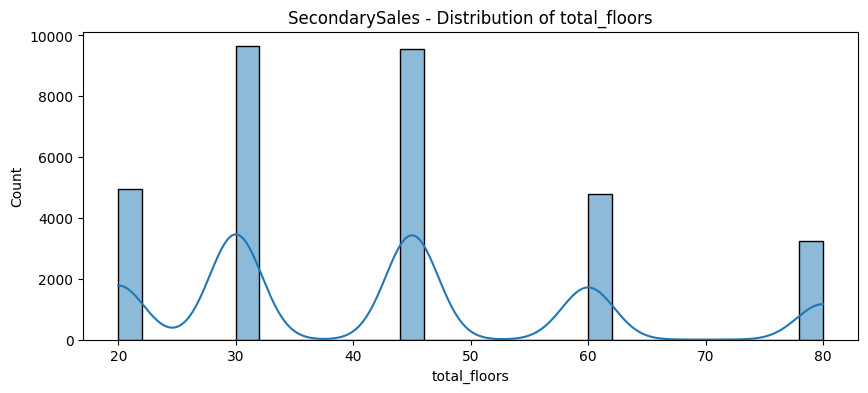

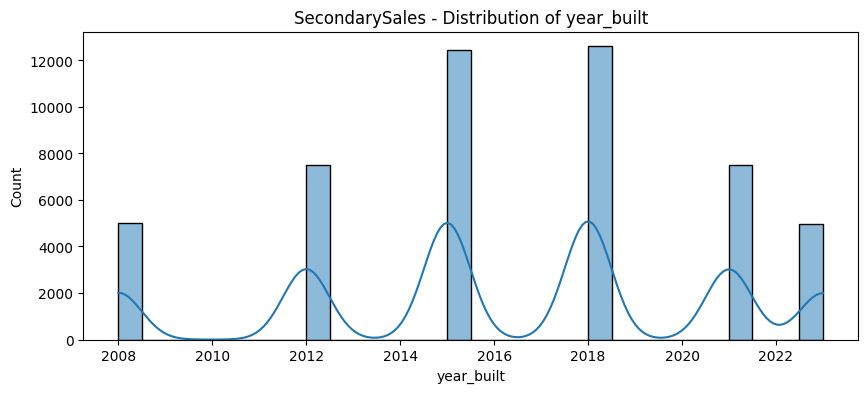

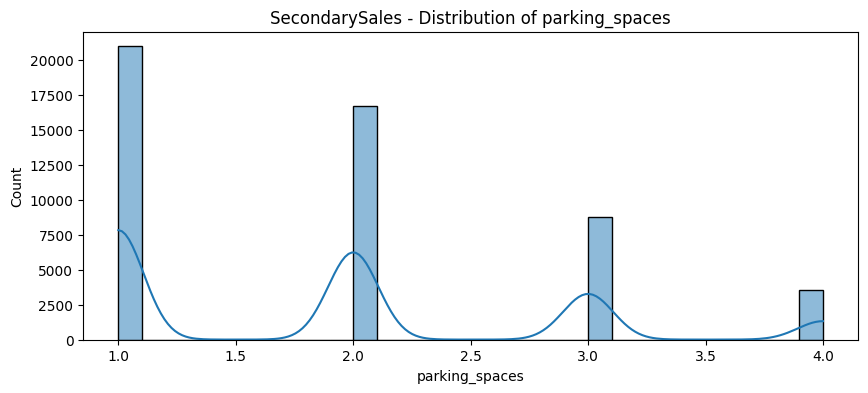

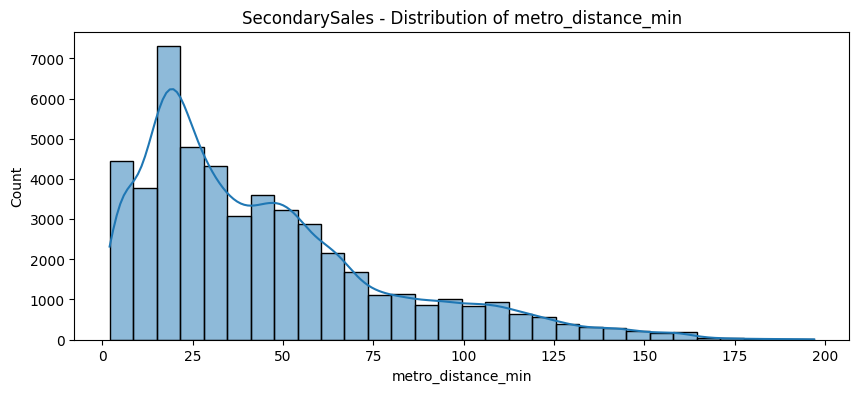

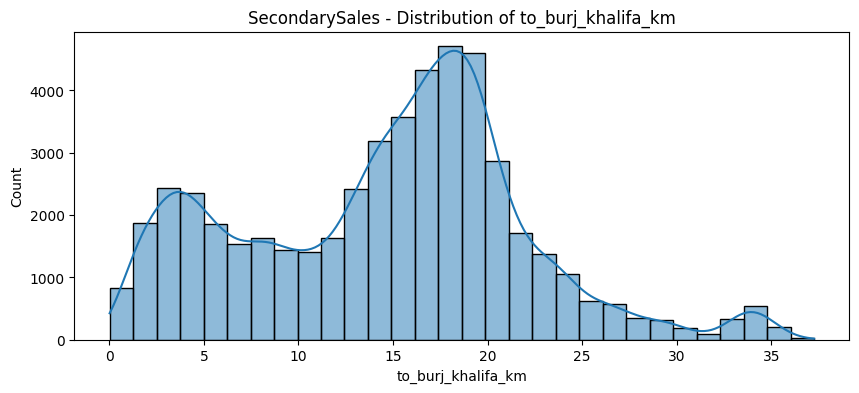

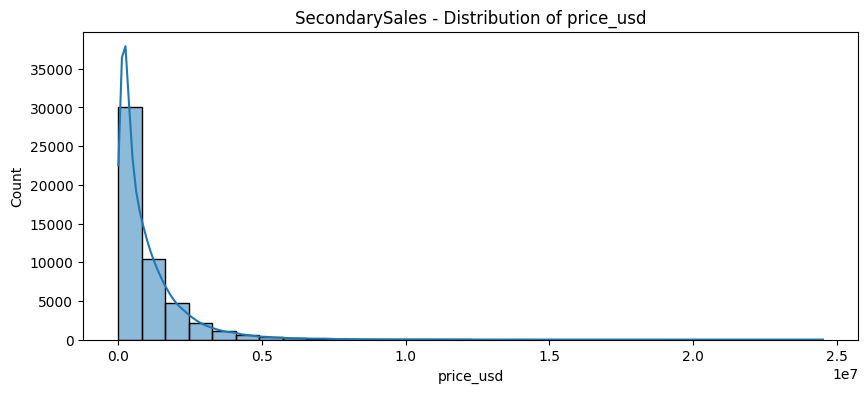

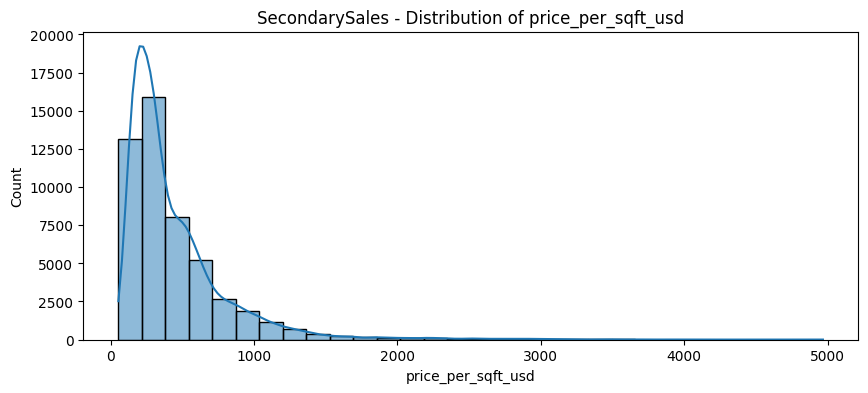

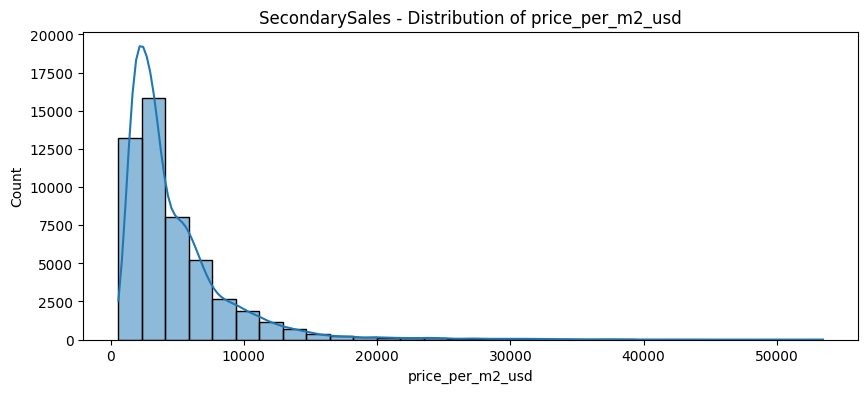

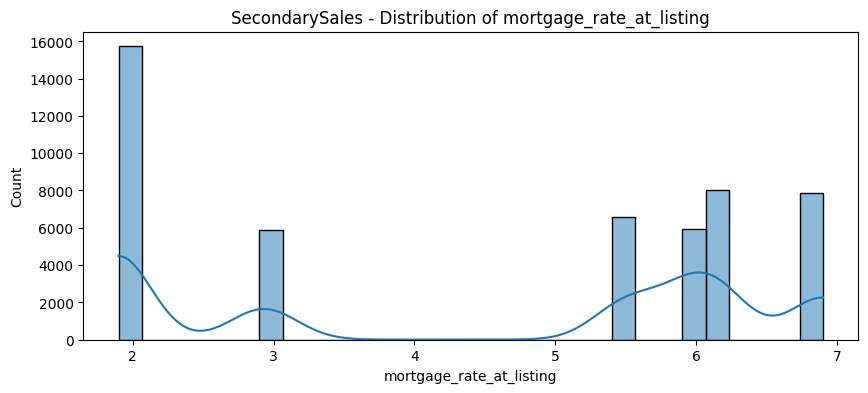


OUTLIER ANALYSIS


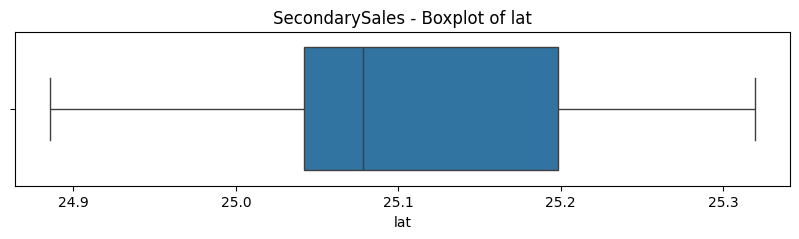

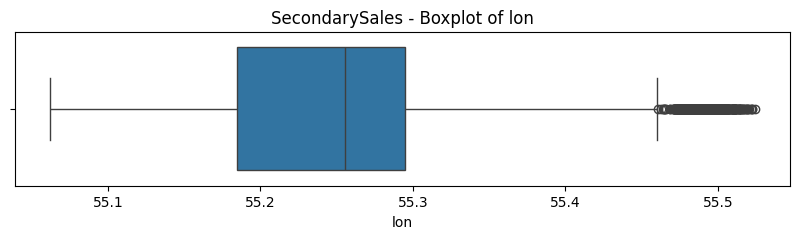

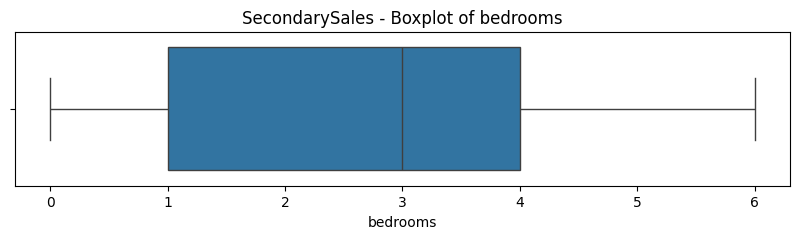

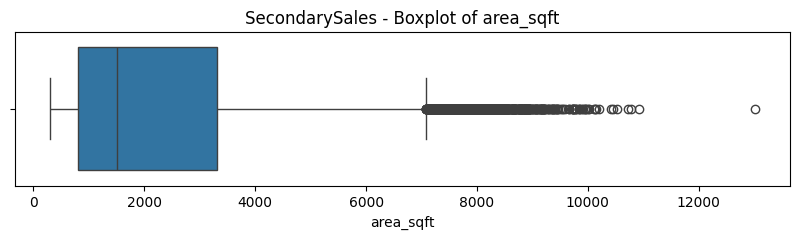

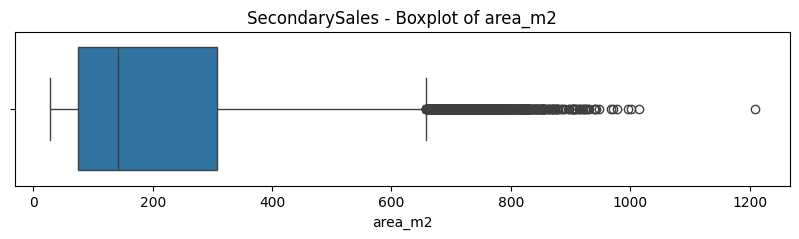

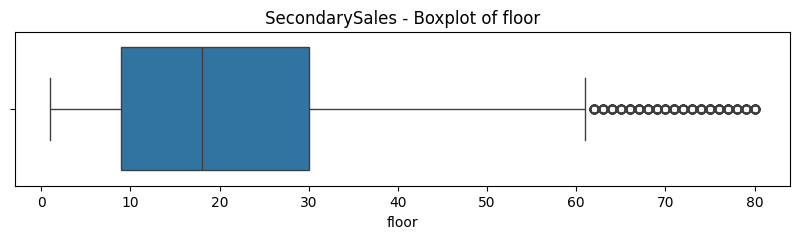

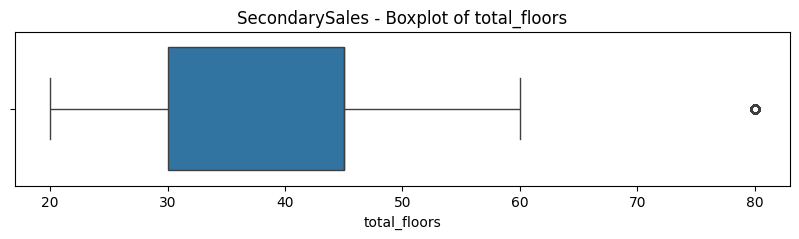

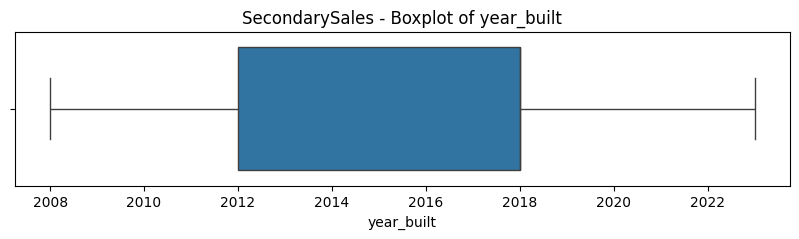

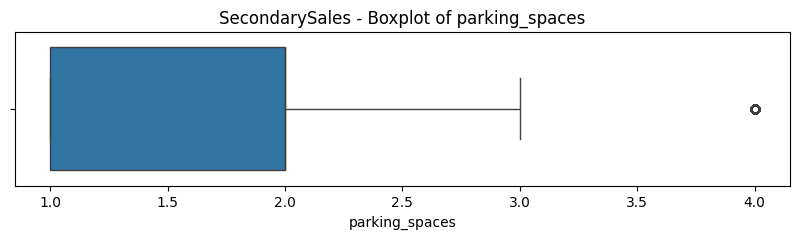

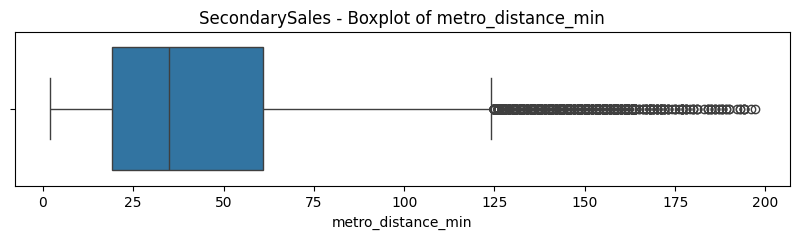

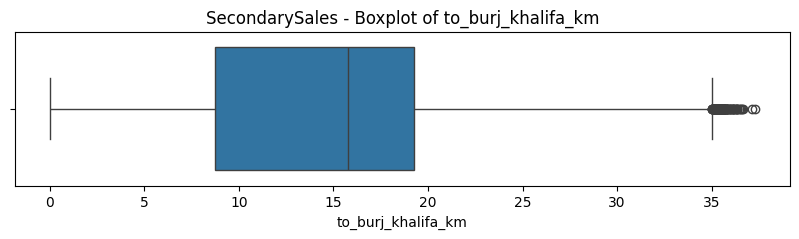

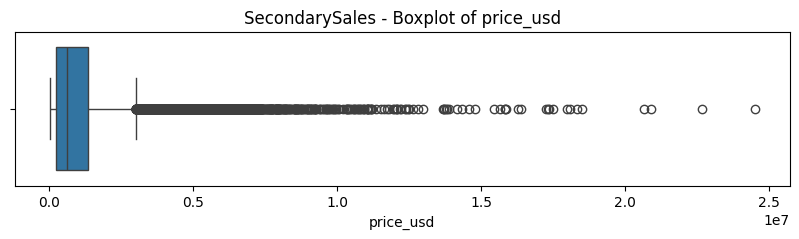

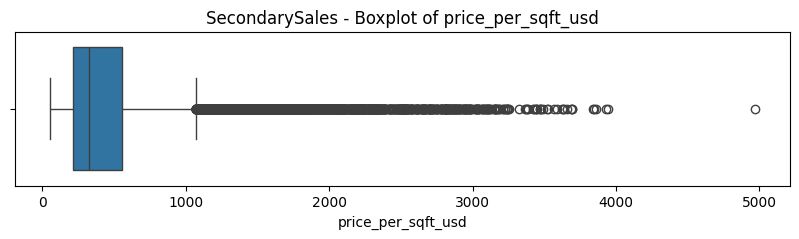

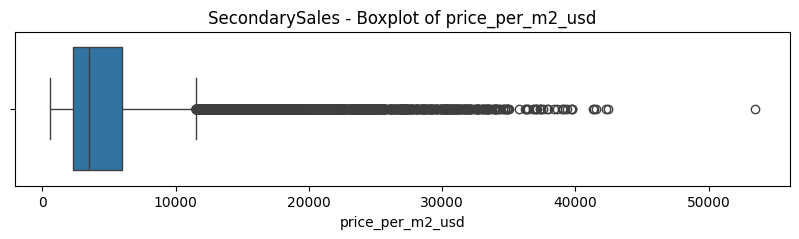

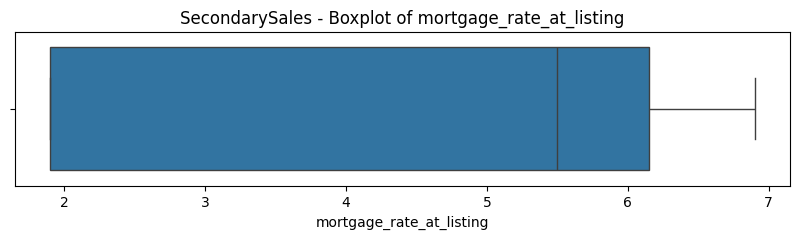


CORRELATION HEATMAP


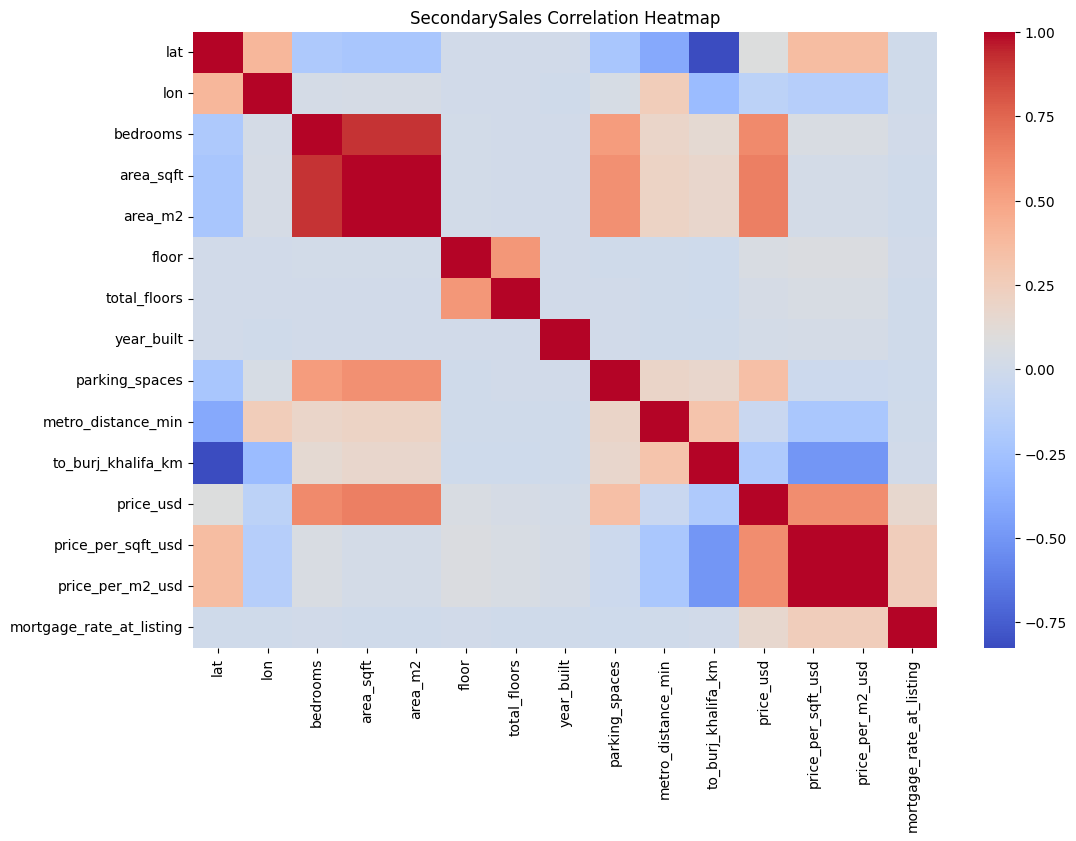


CATEGORICAL FEATURES

Top 10 Categories in id


id
S000001    1
S000002    1
S000003    1
S000004    1
S000005    1
S000006    1
S000007    1
S000008    1
S000009    1
S000010    1
Name: count, dtype: int64


Top 10 Categories in date_listed


date_listed
2024-08-22    39
2025-06-14    38
2025-06-03    37
2023-11-01    36
2023-03-03    35
2024-09-17    35
2025-02-18    34
2024-03-06    34
2021-09-22    33
2022-08-28    33
Name: count, dtype: int64


Top 10 Categories in community


...


Duplicate Rows: 0

Unique Values Per Column


,Column,Unique Values
0,year_month,76
1,community,84
2,zone,52
3,is_freehold,2
4,secondary_price_per_sqft_usd,1155
5,secondary_price_per_m2_usd,4425
6,offplan_price_per_sqft_usd,1245
7,rental_price_per_sqft_annual_usd,131
8,n_listings_secondary,165
9,n_listings_offplan,76



Statistical Summary


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
year_month,6384,76,2020-01,84,NaN,NaN,NaN,NaN,NaN,NaN,NaN
community,6384,84,Palm Jumeirah,76,NaN,NaN,NaN,NaN,NaN,NaN,NaN
zone,6384,52,Jumeirah,608,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_freehold,6384,2,True,5624,NaN,NaN,NaN,NaN,NaN,NaN,NaN
secondary_price_per_sqft_usd,6384.0,NaN,NaN,NaN,485.005482,327.650651,100.0,267.0,384.0,632.0,2610.0
secondary_price_per_m2_usd,6384.0,NaN,NaN,NaN,5220.567043,3526.880318,1079.0,2878.0,4131.0,6800.5,28093.0
offplan_price_per_sqft_usd,5624.0,NaN,NaN,NaN,566.542141,370.371843,107.0,310.0,459.0,729.0,2829.0
rental_price_per_sqft_annual_usd,6384.0,NaN,NaN,NaN,31.526786,21.303818,7.0,17.0,25.0,41.0,170.0
n_listings_secondary,6384.0,NaN,NaN,NaN,96.252976,46.973202,15.0,55.0,97.0,137.0,179.0
n_listings_offplan,6384.0,NaN,NaN,NaN,37.66651,24.416278,0.0,17.0,38.0,58.0,79.0



Memory Usage: 1.52 MB

NUMERICAL FEATURE DISTRIBUTIONS


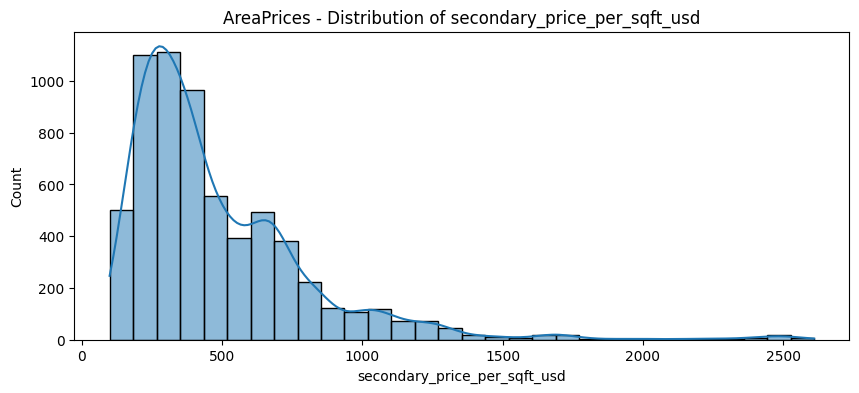

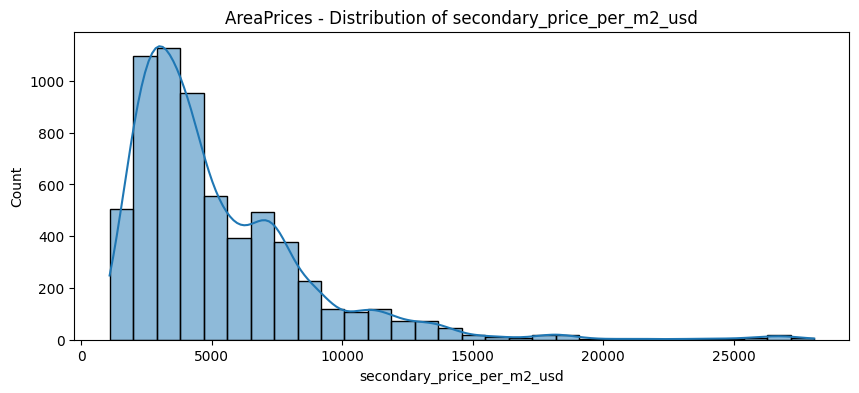

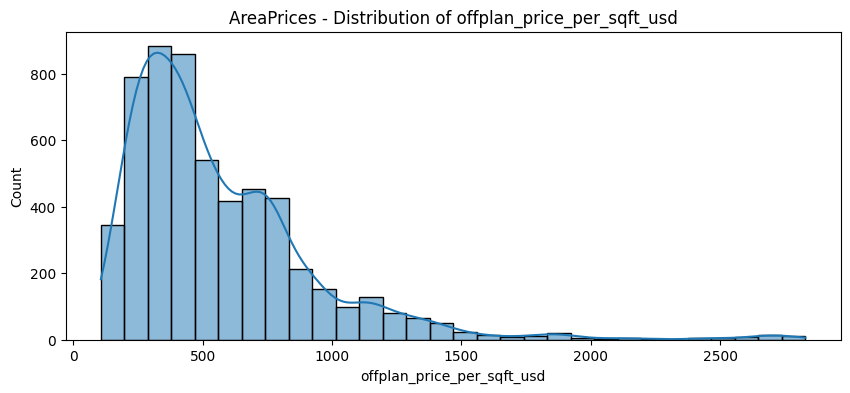

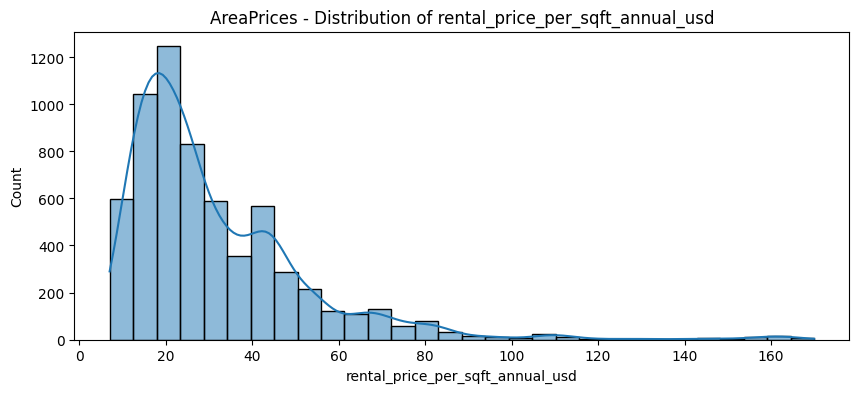

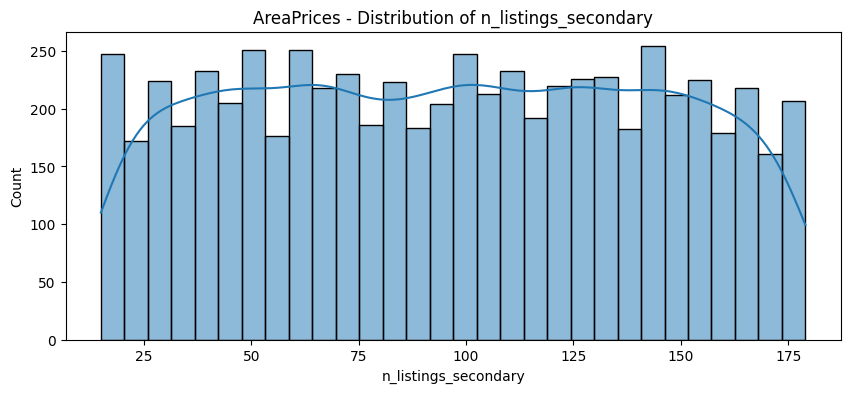

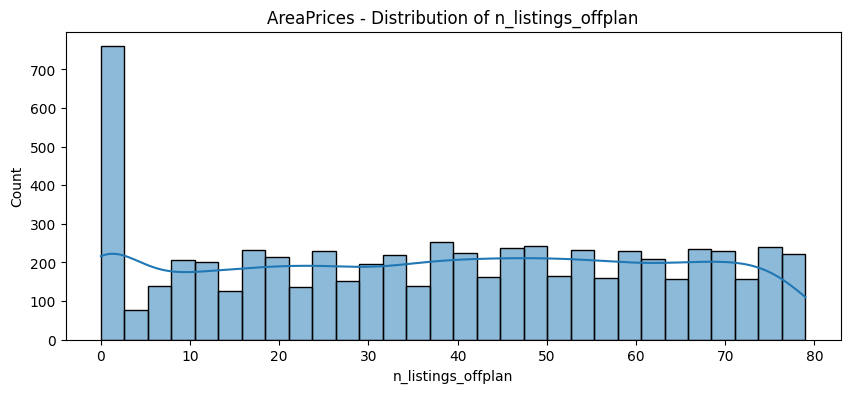

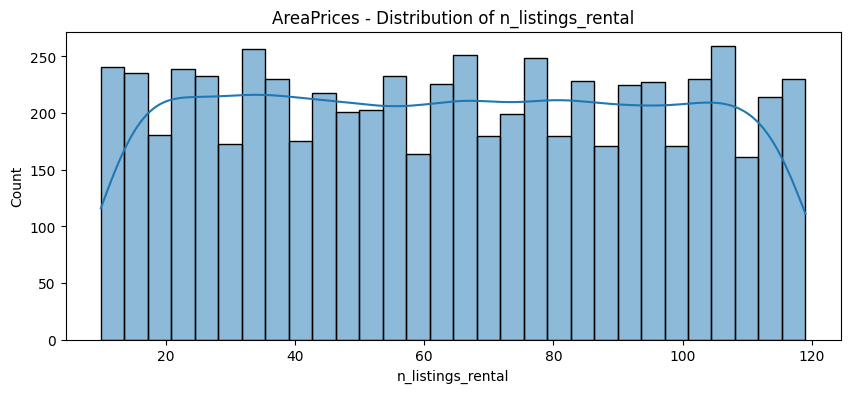

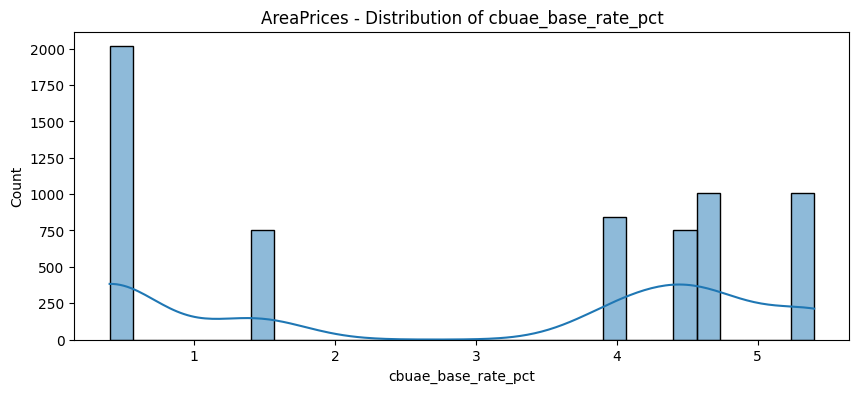

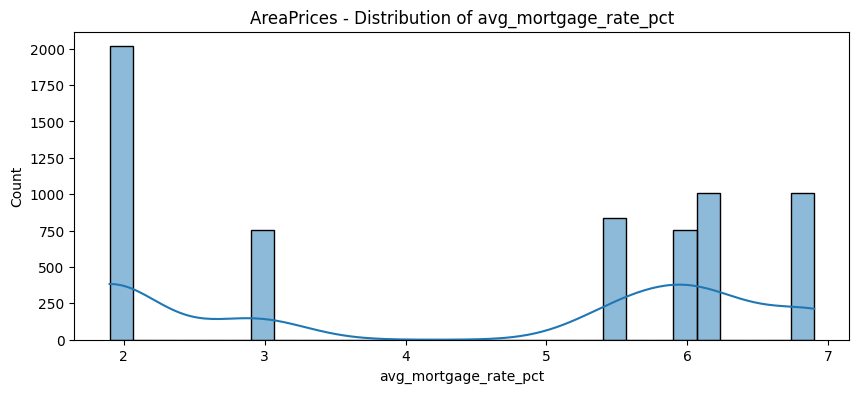


OUTLIER ANALYSIS


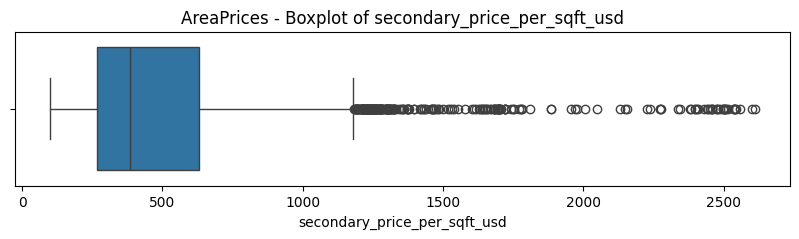

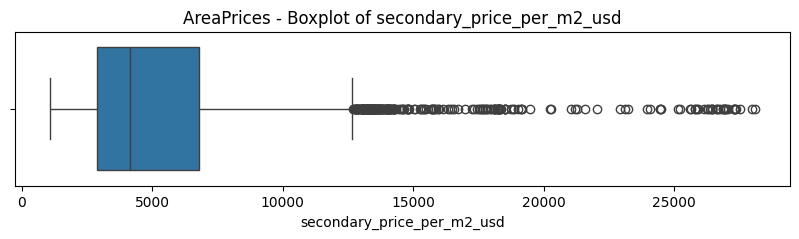

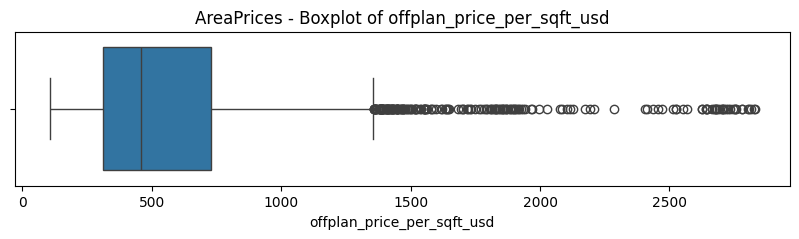

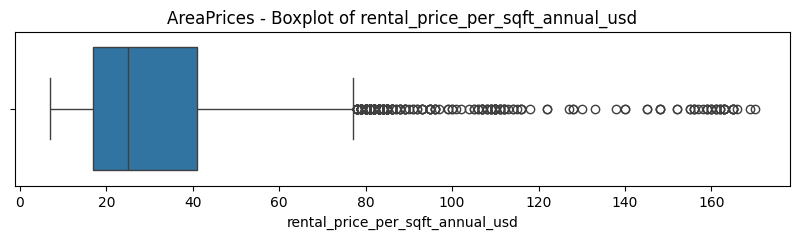

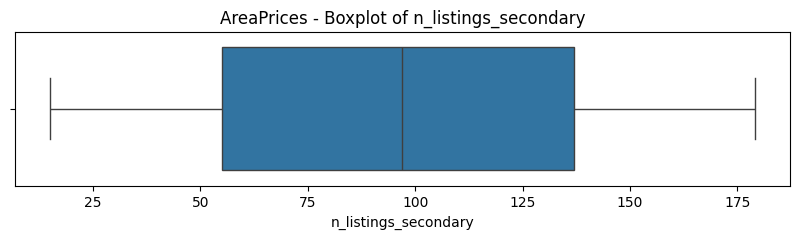

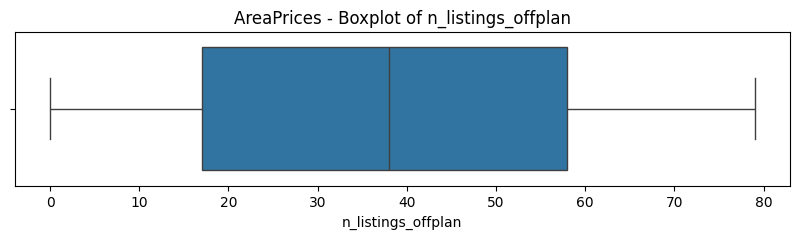

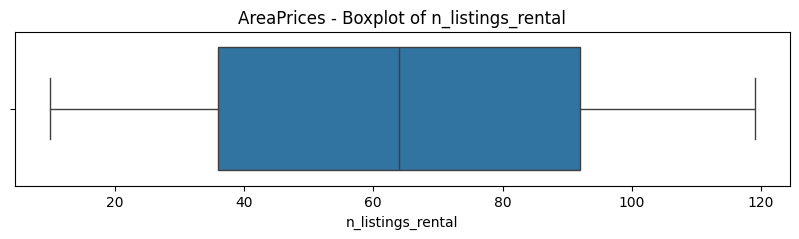

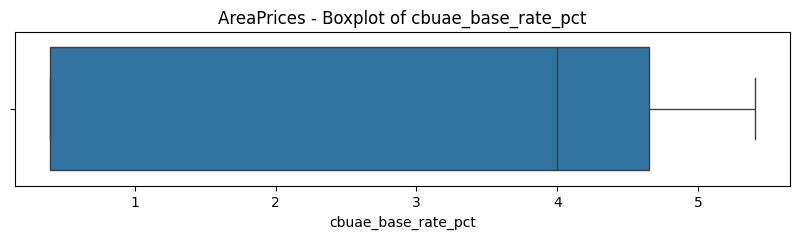

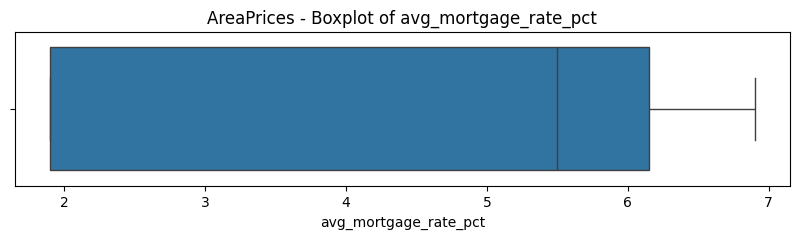


CORRELATION HEATMAP


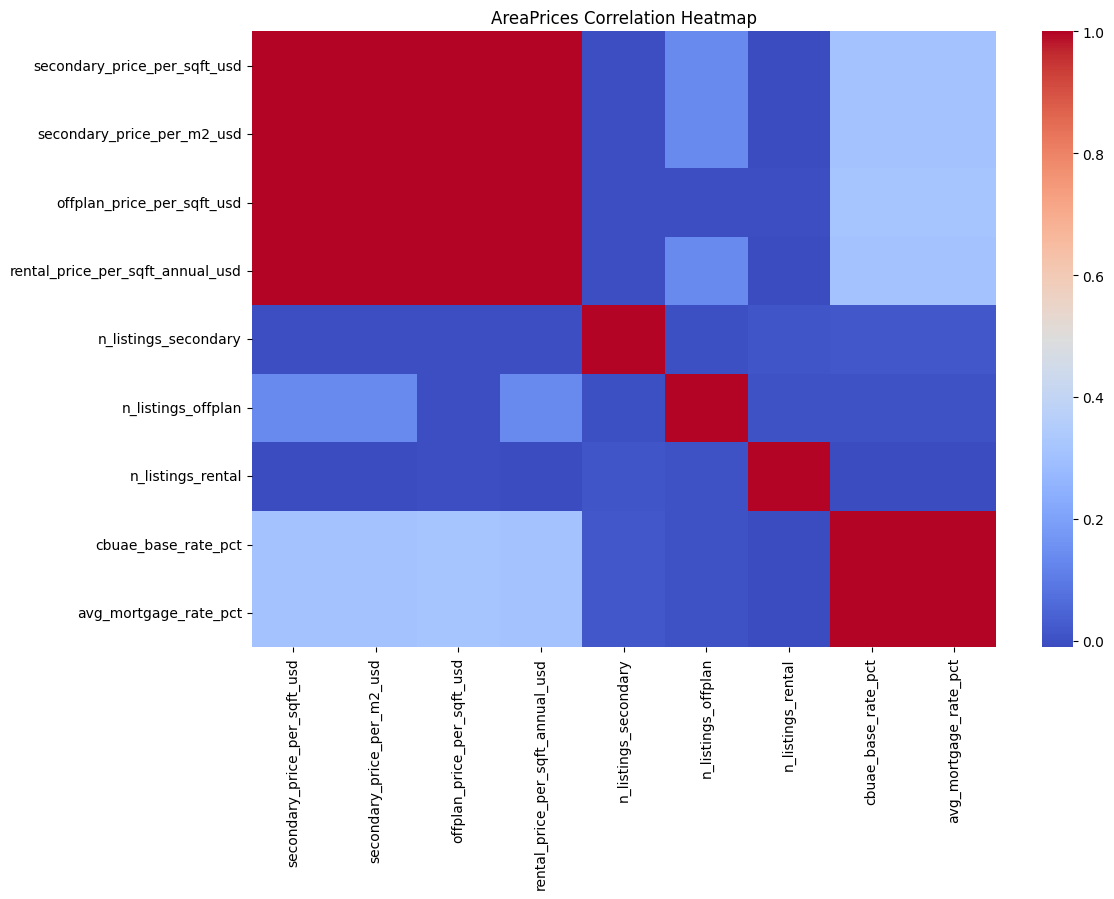


CATEGORICAL FEATURES

Top 10 Categories in year_month


year_month
2020-01    84
2020-02    84
2020-03    84
2020-04    84
2020-05    84
2020-06    84
2020-07    84
2020-08    84
2020-09    84
2020-10    84
Name: count, dtype: int64


Top 10 Categories in community


community
Palm Jumeirah          76
Jumeirah Bay Island    76
Bluewaters Island      76
Emirates Hills         76
Pearl Jumeira          76
Downtown Dubai         76
Business Bay           76
DIFC                   76
City Walk              76
Dubai Marina           76
Name: count, dtype: int64


Top 10 Categories in zone


zone
Jumeirah               608
Dubailand              532
Emirates Living        380
Arabian Ranches        304
Dubai Marina           304
Mohammed Bin Rashid    152
DIP                    152
Al Barsha              152
Damac Hills            152
Dubai South            152
Name: count, dtype: int64


DATASET COMPARISON SUMMARY


,Dataset,Rows,Columns,Missing Values,Duplicates,Memory(MB)
0,Rentals,25000,24,0,0,17.46
1,OffPlan,12000,28,0,0,10.46
2,Metro,55,6,0,0,0.01
3,SecondarySales,50000,29,35640,0,39.02
4,AreaPrices,6384,13,760,0,1.52



EDA COMPLETED SUCCESSFULLY!


In [3]:

# STORE DATASETS
# ==============================

datasets = {
    "Rentals": rentals,
    "OffPlan": off_plan,
    "Metro": metro,
    "SecondarySales": secondary,
    "AreaPrices": area_prices
}

# ==============================
# EDA START
# ==============================

for name, df in datasets.items():

    print("\n" + "="*100)
    print(f"DATASET : {name}")
    print("="*100)

    # --------------------------
    # BASIC INFO
    # --------------------------
    print("\nShape:", df.shape)

    print("\nColumns:")
    print(df.columns.tolist())

    print("\nData Types:")
    print(df.dtypes)

    print("\nFirst 5 Rows:")
    display(df.head())

    # --------------------------
    # MISSING VALUES
    # --------------------------
    print("\nMISSING VALUES")

    missing = df.isnull().sum()

    missing = missing[missing > 0]

    if len(missing) > 0:

        missing_df = pd.DataFrame({
            "Missing Count": missing,
            "Percentage": round(
                missing/len(df)*100,2
            )
        }).sort_values(
            "Percentage",
            ascending=False
        )

        display(missing_df)

    else:
        print("No Missing Values Found")

    # --------------------------
    # DUPLICATES
    # --------------------------
    print("\nDuplicate Rows:", df.duplicated().sum())

    # --------------------------
    # UNIQUE VALUES
    # --------------------------
    print("\nUnique Values Per Column")

    unique_df = pd.DataFrame({
        "Column": df.columns,
        "Unique Values":
        [df[col].nunique() for col in df.columns]
    })

    display(unique_df)

    # --------------------------
    # STATISTICS
    # --------------------------
    print("\nStatistical Summary")

    try:
        display(df.describe(include='all').T)
    except:
        pass

    # --------------------------
    # MEMORY USAGE
    # --------------------------
    mem = df.memory_usage(
        deep=True
    ).sum()/1024**2

    print(f"\nMemory Usage: {mem:.2f} MB")

    # --------------------------
    # NUMERICAL FEATURES
    # --------------------------
    num_cols = df.select_dtypes(
        include=np.number
    ).columns

    if len(num_cols) > 0:

        print("\nNUMERICAL FEATURE DISTRIBUTIONS")

        for col in num_cols:

            plt.figure(figsize=(10,4))

            sns.histplot(
                df[col],
                kde=True,
                bins=30
            )

            plt.title(
                f"{name} - Distribution of {col}"
            )

            plt.show()

        print("\nOUTLIER ANALYSIS")

        for col in num_cols:

            plt.figure(figsize=(10,2))

            sns.boxplot(
                x=df[col]
            )

            plt.title(
                f"{name} - Boxplot of {col}"
            )

            plt.show()

        if len(num_cols) > 1:

            print("\nCORRELATION HEATMAP")

            plt.figure(figsize=(12,8))

            corr = df[num_cols].corr()

            sns.heatmap(
                corr,
                annot=False,
                cmap='coolwarm'
            )

            plt.title(
                f"{name} Correlation Heatmap"
            )

            plt.show()

    # --------------------------
    # CATEGORICAL FEATURES
    # --------------------------
    cat_cols = df.select_dtypes(
        include='object'
    ).columns

    if len(cat_cols) > 0:

        print("\nCATEGORICAL FEATURES")

        for col in cat_cols:

            print(f"\nTop 10 Categories in {col}")

            display(
                df[col]
                .value_counts()
                .head(10)
            )

# ==============================
# DATASET COMPARISON
# ==============================

print("\n" + "="*100)
print("DATASET COMPARISON SUMMARY")
print("="*100)

summary = []

for name, df in datasets.items():

    summary.append({
        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Missing Values":
        df.isnull().sum().sum(),
        "Duplicates":
        df.duplicated().sum(),
        "Memory(MB)":
        round(
            df.memory_usage(deep=True).sum()/1024**2,
            2
        )
    })

summary_df = pd.DataFrame(summary)

display(summary_df)

print("\nEDA COMPLETED SUCCESSFULLY!")

## Thank You......please upvote